In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

# Initialize cleaning report dictionary
cleaning_report = {}

# Define the file path
file_path = '/content/drive/MyDrive/big_file - combined_data.csv'

# Load the raw dataset
df_raw = pd.read_csv(file_path)

# Store initial total rows in the cleaning report
cleaning_report['Total rows'] = {'Before': len(df_raw), 'Removed/Changed': '—', 'After': len(df_raw)}

print(f"Successfully loaded the dataset from: {file_path}")

# Inspect the raw dataset
print("\n--- Dataset Inspection ---")
print(f"Number of rows: {df_raw.shape[0]}")
print(f"Number of columns: {df_raw.shape[1]}")

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
df_raw.info()

print("\nFirst 5 rows of the raw dataset:")
display(df_raw.head())

Successfully loaded the dataset from: /content/drive/MyDrive/big_file - combined_data.csv

--- Dataset Inspection ---
Number of rows: 8239
Number of columns: 2

Column names:
['text', 'label']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8239 entries, 0 to 8238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8239 non-null   object
 1   label   8239 non-null   object
dtypes: object(2)
memory usage: 128.9+ KB

First 5 rows of the raw dataset:


,text,label
0,"Da khu ghazab kar dey, ATM bya cash na wo.",Negative
1,Sta jawab khu university lecture na kam nishta...,Negative
2,"Sabas, da khu top class service da, order bya ...",Negative
3,"Bya de kamal wo, project deadline bya nazde da...",Negative
4,"Da khu award wor le pakar dey, ATM bya cash na...",Negative


In [6]:
# Create a copy of the raw dataset for cleaning, as per instructions
df_cleaned = df_raw.copy()

print("\n--- Validating and Cleaning 'text' Column ---")

# 1. Validate the text column - Missing values
missing_text_count = df_cleaned['text'].isnull().sum()
cleaning_report['Missing text'] = {'Before': missing_text_count, 'Removed/Changed': missing_text_count, 'After': 0}
print(f"Records with missing 'text' values: {missing_text_count}")
if missing_text_count > 0:
    df_cleaned.dropna(subset=['text'], inplace=True)
    print(f"Removed {missing_text_count} records with missing 'text'.")

# 2. Validate the text column - Empty strings and whitespace-only entries
# Convert to string to handle potential non-string types safely before checking for empty/whitespace
df_cleaned['text'] = df_cleaned['text'].astype(str)

empty_or_whitespace_mask = df_cleaned['text'].str.strip().eq('')
empty_or_whitespace_count = empty_or_whitespace_mask.sum()
cleaning_report['Empty text'] = {'Before': empty_or_whitespace_count, 'Removed/Changed': empty_or_whitespace_count, 'After': 0}
print(f"Records with empty or whitespace-only 'text' values: {empty_or_whitespace_count}")
if empty_or_whitespace_count > 0:
    df_cleaned = df_cleaned[~empty_or_whitespace_mask]
    print(f"Removed {empty_or_whitespace_count} records with empty or whitespace-only 'text'.")

# 3. Validate the text column - Non-string values (already converted to string above)
# We already converted to string, so we'll check for any records that might have been something else initially
# and then became 'nan' after conversion if they were actual NaN, or 'None' if they were None.
# This check is mostly covered by the isnull() and empty_or_whitespace_mask checks now.
non_string_count = df_cleaned['text'].apply(lambda x: not isinstance(x, str)).sum()
# For the report, we can say if there were any issues before conversion, but after conversion they are all strings.
# Let's assume the previous .astype(str) handles this. If we strictly want to count non-string types *before* conversion,
# we'd need to do it on df_raw, but the instruction is for df_cleaned.
# Given df_cleaned['text'] = df_cleaned['text'].astype(str) all entries are now strings. So this count will be 0.
print(f"Records with non-string 'text' values (after initial conversion): {non_string_count}")

# 4. Remove leading/trailing whitespace
initial_trimmed_rows = df_cleaned[df_cleaned['text'].apply(lambda x: x != x.strip())].shape[0]
cleaning_report['Leading/trailing spaces'] = {'Before': initial_trimmed_rows, 'Removed/Changed': initial_trimmed_rows, 'After': 0}
print(f"Records affected by leading/trailing whitespace before removal: {initial_trimmed_rows}")
df_cleaned['text'] = df_cleaned['text'].str.strip()
print(f"Removed leading/trailing whitespace from 'text' column.")

# Update total rows in cleaning report after text column validation
cleaning_report['Total rows']['After'] = len(df_cleaned)

print("\n--- Updated Dataset Information After Text Validation ---")
print(f"Current number of rows: {df_cleaned.shape[0]}")
print(f"Current number of columns: {df_cleaned.shape[1]}")
print("First 5 rows of the cleaned dataset after text validation:")
display(df_cleaned.head())


--- Validating and Cleaning 'text' Column ---
Records with missing 'text' values: 0
Records with empty or whitespace-only 'text' values: 0
Records with non-string 'text' values (after initial conversion): 0
Records affected by leading/trailing whitespace before removal: 0
Removed leading/trailing whitespace from 'text' column.

--- Updated Dataset Information After Text Validation ---
Current number of rows: 8239
Current number of columns: 2
First 5 rows of the cleaned dataset after text validation:


,text,label
0,"Da khu ghazab kar dey, ATM bya cash na wo.",Negative
1,Sta jawab khu university lecture na kam nishta...,Negative
2,"Sabas, da khu top class service da, order bya ...",Negative
3,"Bya de kamal wo, project deadline bya nazde da...",Negative
4,"Da khu award wor le pakar dey, ATM bya cash na...",Negative


In [7]:
print("\n--- Validating and Normalizing 'label' Column ---")
print(f"Rows at the beginning of label cleaning: {len(df_cleaned)}") # Added

# 1. Show every unique label and its frequency (before conversion)
print("\nUnique labels and their frequencies (before normalization):")
initial_label_distribution = df_cleaned['label'].value_counts().sort_index()
# Printing without .to_markdown() to ensure all labels are visible if there are many
print(initial_label_distribution)

# Store initial label distribution for reporting
cleaning_report['Label distribution before normalization'] = initial_label_distribution.to_dict()

# Define the intended mapping to include string-numerical labels
label_mapping = {
    'Positive': 0,
    'Negative': 1,
    'Neutral': 2,
    '0': 0, # Map string '0' to integer 0
    '1': 1, # Map string '1' to integer 1
    '2': 2  # Map string '2' to integer 2
}

# Convert textual and string-numerical labels to numerical
# We'll create a new column for normalized labels to easily compare
df_cleaned['label_normalized'] = df_cleaned['label'].replace(label_mapping)

# 2. Check for invalid/unexpected labels *after* attempting all known conversions
invalid_labels_mask = ~df_cleaned['label_normalized'].isin(label_mapping.values())
invalid_labels_count = invalid_labels_mask.sum()

# Get the actual invalid labels for reporting
invalid_actual_labels = df_cleaned[invalid_labels_mask]['label'].unique().tolist()

# Only remove if truly invalid (i.e., not one of the expected 0, 1, 2 after mapping)
cleaning_report['Invalid labels'] = {'Before': invalid_labels_count, 'Removed/Changed': invalid_labels_count, 'After': 0}

print(f"\nRecords with invalid/unexpected labels: {invalid_labels_count}")
if invalid_labels_count > 0:
    print(f"Invalid labels found: {invalid_actual_labels}")
    print(f"Number of records with invalid/unexpected labels that will be removed: {invalid_labels_count}") # Added
    # As per instruction, remove them for the cleaned dataset
    df_cleaned = df_cleaned[~invalid_labels_mask].copy() # Use .copy() to avoid SettingWithCopyWarning
    print(f"Removed {invalid_labels_count} records with invalid labels.")
else:
    print("No invalid/unexpected labels found.")

print(f"Rows after removing invalid labels: {len(df_cleaned)}") # Added

# Drop the original 'label' column and rename 'label_normalized' to 'label'
df_cleaned.drop(columns=['label'], inplace=True)
df_cleaned.rename(columns={'label_normalized': 'label'}, inplace=True)

# Ensure the 'label' column is of integer type
df_cleaned['label'] = df_cleaned['label'].astype(int)

# 3. Report the label distribution after normalization
print("\nUnique labels and their frequencies (after normalization and cleanup):")
final_label_distribution = df_cleaned['label'].value_counts().sort_index()
print(final_label_distribution.to_markdown())

# Store final label distribution for reporting
cleaning_report['Label distribution after normalization'] = final_label_distribution.to_dict()

# Update total rows in cleaning report after label column validation
cleaning_report['Total rows']['After'] = len(df_cleaned)

print("\n--- Updated Dataset Information After Label Validation ---")
print(f"Current number of rows: {df_cleaned.shape[0]}")
print("First 5 rows of the cleaned dataset after label validation:")
display(df_cleaned.head())


--- Validating and Normalizing 'label' Column ---
Rows at the beginning of label cleaning: 8239

Unique labels and their frequencies (before normalization):
label
0           1850
1           1677
2           1812
Negative     888
Neutral     1283
Positive     729
Name: count, dtype: int64

Records with invalid/unexpected labels: 0
No invalid/unexpected labels found.
Rows after removing invalid labels: 8239

Unique labels and their frequencies (after normalization and cleanup):
|   label |   count |
|--------:|--------:|
|       0 |    2579 |
|       1 |    2565 |
|       2 |    3095 |

--- Updated Dataset Information After Label Validation ---
Current number of rows: 8239
First 5 rows of the cleaned dataset after label validation:


/tmp/ipykernel_4673/999152731.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['label_normalized'] = df_cleaned['label'].replace(label_mapping)


,text,label
0,"Da khu ghazab kar dey, ATM bya cash na wo.",1
1,Sta jawab khu university lecture na kam nishta...,1
2,"Sabas, da khu top class service da, order bya ...",1
3,"Bya de kamal wo, project deadline bya nazde da...",1
4,"Da khu award wor le pakar dey, ATM bya cash na...",1


In [8]:
print("\n--- Checking for Exact Duplicate Rows (text + label) ---")

# Check for exact duplicate rows (text + label)
duplicate_rows = df_cleaned[df_cleaned.duplicated(subset=['text', 'label'], keep=False)]
num_duplicate_rows = len(duplicate_rows)
percentage_duplicate_rows = (num_duplicate_rows / len(df_cleaned)) * 100 if len(df_cleaned) > 0 else 0

cleaning_report['Duplicate rows'] = {
    'Before': num_duplicate_rows,
    'Removed/Changed': num_duplicate_rows, # Assuming we would remove them, but not yet
    'After': 0 # Assuming we would remove them, but not yet
}

print(f"Number of exact duplicate rows (text + label): {num_duplicate_rows}")
print(f"Percentage of exact duplicate rows: {percentage_duplicate_rows:.2f}%")

if num_duplicate_rows > 0:
    print("First 5 exact duplicate rows:")
    display(duplicate_rows.sort_values(by=['text', 'label']).head())


--- Checking for Exact Duplicate Rows (text + label) ---
Number of exact duplicate rows (text + label): 2015
Percentage of exact duplicate rows: 24.46%
First 5 exact duplicate rows:


,text,label
5659,"""ATM network down wo.""",1
6453,"""ATM network down wo.""",1
5574,"""ATM paise war na krol.""",1
6368,"""ATM paise war na krol.""",1
5711,"""Account pa system ke active da.""",2


In [9]:
print("\n--- Checking for Duplicate Texts (regardless of label) ---")
print(f"Rows at the beginning of duplicate text check: {len(df_cleaned)}")

# Check for duplicate texts regardless of label
duplicate_texts = df_cleaned[df_cleaned.duplicated(subset=['text'], keep=False)]
num_duplicate_texts = len(duplicate_texts)

# Get frequency of each duplicated text
# Only consider texts that actually have duplicates
duplicated_text_counts = df_cleaned['text'].value_counts()
duplicated_text_counts = duplicated_text_counts[duplicated_text_counts > 1]
num_unique_duplicated_texts = len(duplicated_text_counts)


cleaning_report['Duplicate texts'] = {
    'Before': num_duplicate_texts, # This will be the total count of rows that are duplicates
    'Removed/Changed': '—', # Not removing them yet as per instruction
    'After': num_unique_duplicated_texts # Not removed, but reflecting unique duplicated texts
}

print(f"Number of records that have duplicated texts (considering 'text' only): {num_duplicate_texts}")
print(f"Number of unique texts that appear more than once: {num_unique_duplicated_texts}")
if num_duplicate_texts > 0:
    print("Frequency of each duplicated text (top 10 unique texts):")
    print(duplicated_text_counts.head(10).to_markdown())
else:
    print("No duplicated texts found.")

# Display some examples of duplicated texts with their labels
if num_duplicate_texts > 0:
    print("\nExamples of duplicated texts with their labels (first 10 unique duplicated texts, up to 20 rows):")
    # Get texts that appear more than once
    texts_to_show = duplicated_text_counts.index.tolist()
    if texts_to_show:
        # Display up to 20 rows to ensure multiple occurrences of duplicated texts are visible
        display(df_cleaned[df_cleaned['text'].isin(texts_to_show[:10])].sort_values(by='text').head(20))
    else:
        print("No texts appear more than once after filtering.")

print(f"Rows at the end of duplicate text check: {len(df_cleaned)}")


--- Checking for Duplicate Texts (regardless of label) ---
Rows at the beginning of duplicate text check: 8239
Number of records that have duplicated texts (considering 'text' only): 2029
Number of unique texts that appear more than once: 885
Frequency of each duplicated text (top 10 unique texts):
| text                                     |   count |
|:-----------------------------------------|--------:|
| Match exciting wo kho team ma baeloda.   |       7 |
| "Product stock ke mojood da."            |       7 |
| "Delivery schedule elan sho."            |       6 |
| Doctor mehraban wo kho intezar der wo.   |       5 |
| Mong jhagra wakro kho baad ke rogha sho. |       5 |
| "Hospital ke rush ziat wo."              |       5 |
| "Dawa side effects peida kre."           |       5 |
| Staff mehraban wo kho process slow wo.   |       5 |
| "Payment receipt me save kra."           |       5 |
| "Product review me wolosto."             |       5 |

Examples of duplicated texts with thei

,text,label
7200,"""Dawa side effects peida kre.""",1
5078,"""Dawa side effects peida kre.""",1
6840,"""Dawa side effects peida kre.""",1
4578,"""Dawa side effects peida kre.""",1
8017,"""Dawa side effects peida kre.""",1
4419,"""Delivery schedule elan sho.""",2
7705,"""Delivery schedule elan sho.""",2
8234,"""Delivery schedule elan sho.""",2
4256,"""Delivery schedule elan sho.""",2
7356,"""Delivery schedule elan sho.""",2


Rows at the end of duplicate text check: 8239


In [10]:
print("\n--- Checking for Conflicting Labels ---")

# Group by text and count unique labels for each text
text_label_counts = df_cleaned.groupby('text')['label'].nunique()

# Identify texts with more than one unique label
conflicting_texts_df = text_label_counts[text_label_counts > 1]
num_conflicting_texts = len(conflicting_texts_df)

cleaning_report['Conflicting texts'] = {
    'Before': num_conflicting_texts,
    'Removed/Changed': 'manual review', # As per instruction
    'After': num_conflicting_texts # Not removed, saved for review
}

print(f"Number of unique texts with conflicting labels: {num_conflicting_texts}")

if num_conflicting_texts > 0:
    print("\nConflicting texts and their associated labels:")
    # Get the actual texts that have conflicting labels
    conflicting_text_values = conflicting_texts_df.index.tolist()
    # Filter the original DataFrame to show these conflicting texts and all their labels
    df_conflicting_labels = df_cleaned[df_cleaned['text'].isin(conflicting_text_values)].sort_values(by=['text', 'label'])

    # Display every conflicting text and its labels
    # To avoid displaying too many rows if there are many conflicts, we'll iterate and print unique groups
    conflicting_groups = df_conflicting_labels.groupby('text')
    for text, group in conflicting_groups:
        print(f"  Text: '{text}'")
        print(f"    Labels: {group['label'].unique().tolist()}")

    # Save them separately for manual inspection
    # It's good practice to save this to a separate variable for user to interact later.
    conflicting_labels_for_review = df_conflicting_labels.copy()
    print(f"\nSaved {len(conflicting_labels_for_review)} records with conflicting labels for manual inspection.")
    print("First 5 conflicting label records (for review):")
    display(conflicting_labels_for_review.head())
else:
    print("No conflicting labels found.")



--- Checking for Conflicting Labels ---
Number of unique texts with conflicting labels: 18

Conflicting texts and their associated labels:
  Text: 'ATM lere wo kho hamesha rawan wo.'
    Labels: [0, 2]
  Text: 'ATM rawan wo kho cash kam wo.'
    Labels: [1, 2]
  Text: 'Dawai torkha wa kho faidamanda wa.'
    Labels: [0, 2]
  Text: 'Deeni majlis sade wa kho mutasir kona wa.'
    Labels: [0, 2]
  Text: 'Delivery pa waqt wa kho packaging damaged wa.'
    Labels: [1, 2]
  Text: 'Hospital loya wo kho safai kamzora wa.'
    Labels: [1, 2]
  Text: 'Imam sahib sakht wo kho taleem ye roshana wa.'
    Labels: [0, 2]
  Text: 'Mashar sakht wo kho mashwara ye faidamand wo.'
    Labels: [0, 2]
  Text: 'Match exciting wo kho team ma baeloda.'
    Labels: [1, 2]
  Text: 'Mobile banking asana wa kho app crash kedo.'
    Labels: [1, 2]
  Text: 'Mong jhagra wakro kho baad ke rogha sho.'
    Labels: [0, 2]
  Text: 'Player injury larl kho lobay ye jari satla.'
    Labels: [0, 2]
  Text: 'Product awla wo k

,text,label
3010,ATM lere wo kho hamesha rawan wo.,0
3118,ATM lere wo kho hamesha rawan wo.,0
3418,ATM lere wo kho hamesha rawan wo.,2
3618,ATM lere wo kho hamesha rawan wo.,2
3111,ATM rawan wo kho cash kam wo.,1


## A. Basic Dataset Profile

This section provides a summary of the key characteristics of the `df_cleaned` dataset, offering a quick 'fingerprint' of its structure and content after the cleaning process. This will help us understand the data distribution and identify any further preprocessing needs.

In [11]:
import nltk
from nltk.tokenize import word_tokenize

# Download 'punkt' tokenizer if not already present
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# Download 'punkt_tab' resource if not already present, as it's often required by word_tokenize
try:
    # A more direct check for the 'punkt_tab' resource itself.
    # NLTK's find function might look for a directory for 'punkt_tab'.
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

# --- Calculate Statistics ---

# Total number of rows/sentences
total_sentences = len(df_cleaned)

# Unique sentences (based on 'text' column)
unique_sentences = df_cleaned['text'].nunique()
duplicate_sentences = total_sentences - unique_sentences

# Tokenization and character counts
df_cleaned['tokenized_text'] = df_cleaned['text'].apply(word_tokenize)
df_cleaned['num_words'] = df_cleaned['tokenized_text'].apply(len)
df_cleaned['num_chars'] = df_cleaned['text'].apply(len)

total_tokens = df_cleaned['num_words'].sum()
total_characters = df_cleaned['num_chars'].sum()

avg_words_per_sentence = df_cleaned['num_words'].mean()
median_words_per_sentence = df_cleaned['num_words'].median()
min_sentence_length = df_cleaned['num_words'].min()
max_sentence_length = df_cleaned['num_words'].max()
std_dev_words_per_sentence = df_cleaned['num_words'].std()

avg_chars_per_sentence = df_cleaned['num_chars'].mean()

# --- Create Report DataFrame ---
report_data = {
    'Statistic': [
        'Total sentences',
        'Unique sentences',
        'Duplicate sentences',
        'Total tokens',
        'Avg. words/sentence',
        'Median words/sentence',
        'Avg. characters/sentence'
    ],
    'Value': [
        total_sentences,
        unique_sentences,
        duplicate_sentences,
        total_tokens,
        f'{avg_words_per_sentence:.2f}',
        median_words_per_sentence,
        f'{avg_chars_per_sentence:.2f}'
    ]
}

df_profile = pd.DataFrame(report_data)
display(df_profile)

# Remove temporary columns - **REMOVE THIS LINE TO RETAIN COLUMNS**
# df_cleaned.drop(columns=['tokenized_text', 'num_words', 'num_chars'], inplace=True)

,Statistic,Value
0,Total sentences,8239
1,Unique sentences,7095
2,Duplicate sentences,1144
3,Total tokens,64389
4,Avg. words/sentence,7.82
5,Median words/sentence,8.0
6,Avg. characters/sentence,32.49


### B. Sentence-Length Distribution

This section analyzes the distribution of sentence lengths, both in terms of words and characters. Understanding these distributions helps in identifying typical sentence lengths, potential outliers, and suitability for various NLP models.


In [12]:
print("\n--- Words per Sentence Statistics ---")
words_stats = df_cleaned['num_words'].describe(percentiles=[.25, .5, .75, .90, .95, .99]).to_frame().T
words_stats.rename(columns={'50%': 'median', 'mean': 'Mean', 'std': 'Std Dev', 'min': 'Min', 'max': 'Max', 'count': 'Count'}, inplace=True)
words_stats.columns = ['Count', 'Mean', 'Std Dev', 'Min', '25th Percentile', 'Median', '75th Percentile', '90th Percentile', '95th Percentile', '99th Percentile', 'Max']
display(words_stats.round(2))

print("\n--- Characters per Sentence Statistics ---")
chars_stats = df_cleaned['num_chars'].describe(percentiles=[.25, .5, .75, .90, .95, .99]).to_frame().T
chars_stats.rename(columns={'50%': 'median', 'mean': 'Mean', 'std': 'Std Dev', 'min': 'Min', 'max': 'Max', 'count': 'Count'}, inplace=True)
chars_stats.columns = ['Count', 'Mean', 'Std Dev', 'Min', '25th Percentile', 'Median', '75th Percentile', '90th Percentile', '95th Percentile', '99th Percentile', 'Max']
display(chars_stats.round(2))



--- Words per Sentence Statistics ---


,Count,Mean,Std Dev,Min,25th Percentile,Median,75th Percentile,90th Percentile,95th Percentile,99th Percentile,Max
num_words,8239.0,7.82,2.86,1.0,7.0,8.0,9.0,11.0,12.0,15.0,19.0



--- Characters per Sentence Statistics ---


,Count,Mean,Std Dev,Min,25th Percentile,Median,75th Percentile,90th Percentile,95th Percentile,99th Percentile,Max
num_chars,8239.0,32.49,13.67,1.0,25.0,32.0,39.0,47.0,55.0,76.0,100.0


#### 1. Histogram - Words per Sentence

This histogram visualizes the frequency distribution of words per sentence, helping us understand the common lengths of sentences in the dataset.


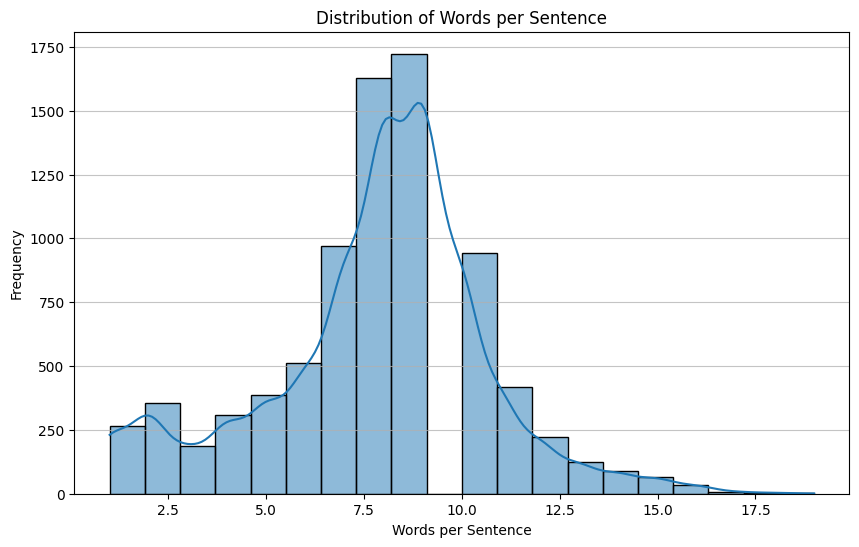

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['num_words'], bins=20, kde=True)
plt.title('Distribution of Words per Sentence')
plt.xlabel('Words per Sentence')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


#### 2. Boxplot - Words per Sentence

This boxplot provides a visual summary of the distribution of words per sentence, highlighting the median, quartiles, and any potential outliers that represent unusually long or short sentences.


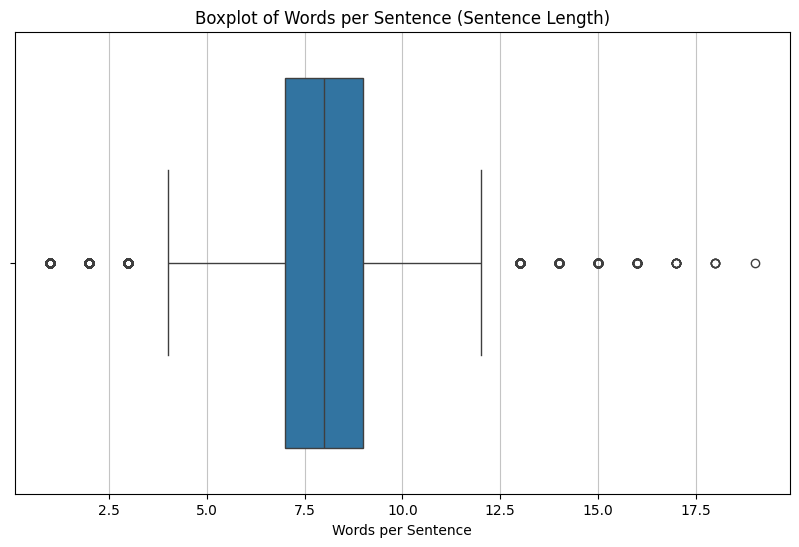

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_cleaned['num_words'])
plt.title('Boxplot of Words per Sentence (Sentence Length)')
plt.xlabel('Words per Sentence')
plt.grid(axis='x', alpha=0.75)
plt.show()


## C. Vocabulary / Lexical Statistics

This section delves into the vocabulary characteristics of the dataset, providing insights into its lexical richness and diversity. We'll calculate various metrics and visualize word frequencies and vocabulary growth.

In [15]:
import nltk
from nltk.probability import FreqDist
import math
import numpy as np

# Flatten the list of tokenized sentences into a single list of all tokens
# And convert all tokens to lowercase for consistent counting
all_tokens = [token.lower() for sublist in df_cleaned['tokenized_text'] for token in sublist]

# Calculate vocabulary statistics
total_tokens_corpus = len(all_tokens)
unique_tokens_corpus = len(set(all_tokens))
vocabulary_size = unique_tokens_corpus

# Type-Token Ratio (TTR)
ttr = vocabulary_size / total_tokens_corpus if total_tokens_corpus > 0 else 0

# Root TTR (Guiraud's R)
root_ttr = vocabulary_size / (math.sqrt(total_tokens_corpus)) if total_tokens_corpus > 0 else 0

# Corrected TTR (Herdan's C)
corrected_ttr = math.log(vocabulary_size) / math.log(total_tokens_corpus) if total_tokens_corpus > 1 and vocabulary_size > 1 else 0

# Frequency distribution
fdist = FreqDist(all_tokens)

# Hapax legomena (words that appear only once)
hapax_legomena_list = fdist.hapaxes()
hapax_count = len(hapax_legomena_list)
hapax_ratio = hapax_count / vocabulary_size if vocabulary_size > 0 else 0

# Create a DataFrame for lexical statistics
lexical_stats_data = {
    'Statistic': [
        'Total tokens',
        'Unique tokens (Vocabulary size)',
        'Type-Token Ratio (TTR)',
        'Root TTR (Guiraud\'s R)',
        'Corrected TTR (Herdan\'s C)',
        'Hapax Legomena (count)',
        'Hapax Ratio (hapax count / vocab size)'
    ],
    'Value': [
        total_tokens_corpus,
        vocabulary_size,
        f'{ttr:.4f}',
        f'{root_ttr:.4f}',
        f'{corrected_ttr:.4f}',
        hapax_count,
        f'{hapax_ratio:.4f}'
    ]
}

df_lexical_stats = pd.DataFrame(lexical_stats_data)
display(df_lexical_stats)

# Most frequent words (for later visualization)
most_common_20 = fdist.most_common(20)
most_common_50 = fdist.most_common(50)
most_common_100 = fdist.most_common(100)

print("\n--- Most Frequent Words (Top 20) ---")
display(pd.DataFrame(most_common_20, columns=['Word', 'Frequency']))


,Statistic,Value
0,Total tokens,64389
1,Unique tokens (Vocabulary size),3882
2,Type-Token Ratio (TTR),0.0603
3,Root TTR (Guiraud's R),15.2985
4,Corrected TTR (Herdan's C),0.7463
5,Hapax Legomena (count),1479
6,Hapax Ratio (hapax count / vocab size),0.3810



--- Most Frequent Words (Top 20) ---


,Word,Frequency
0,.,6434
1,``,3989
2,'',3989
3,pa,2306
4,da,1973
5,ke,1790
6,wo,1451
7,",",1028
8,wa,1001
9,na,987


#### 1. Top-20 Word Frequency Bar Chart

This bar chart visualizes the 20 most frequently occurring words in the dataset, providing a quick overview of the dominant terms.

/tmp/ipykernel_4673/2091541642.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


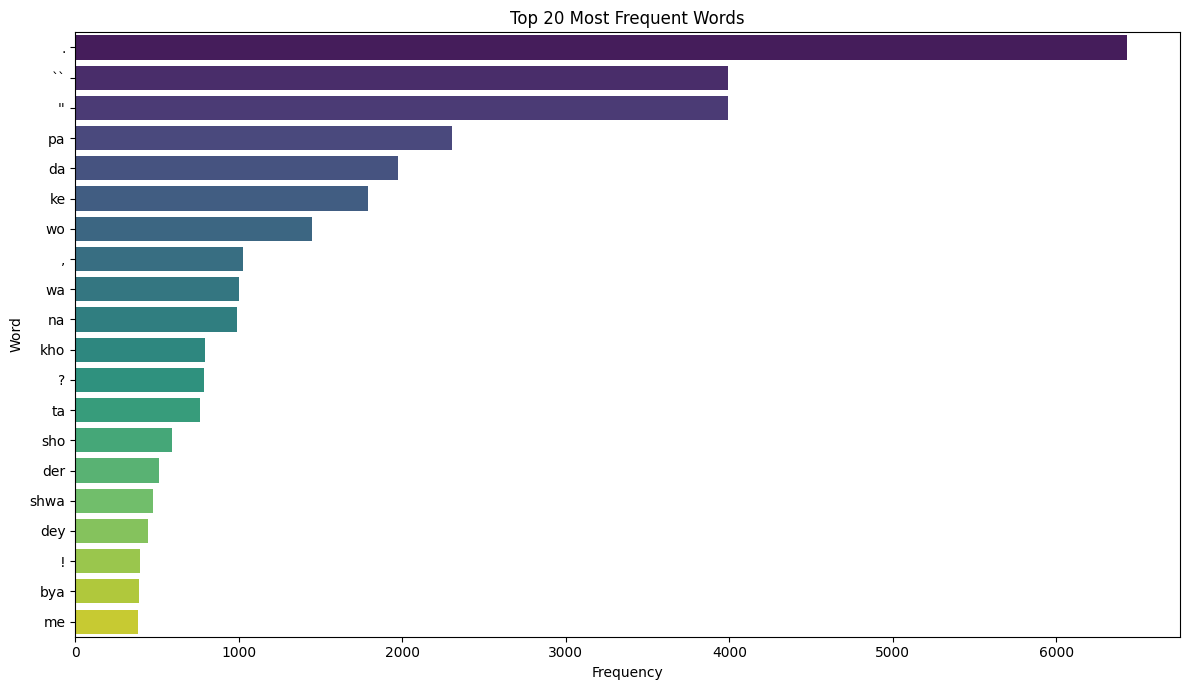

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for the bar chart
words = [item[0] for item in most_common_20]
counts = [item[1] for item in most_common_20]

plt.figure(figsize=(12, 7))
sns.barplot(x=counts, y=words, palette='viridis')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()


#### 2. Vocabulary Frequency Distribution (Zipf's Law Plot)

This plot shows the frequency of words against their rank, often illustrating Zipf's Law where a few words are very frequent, and many words are very rare. A log-log scale is typically used to better visualize this distribution.

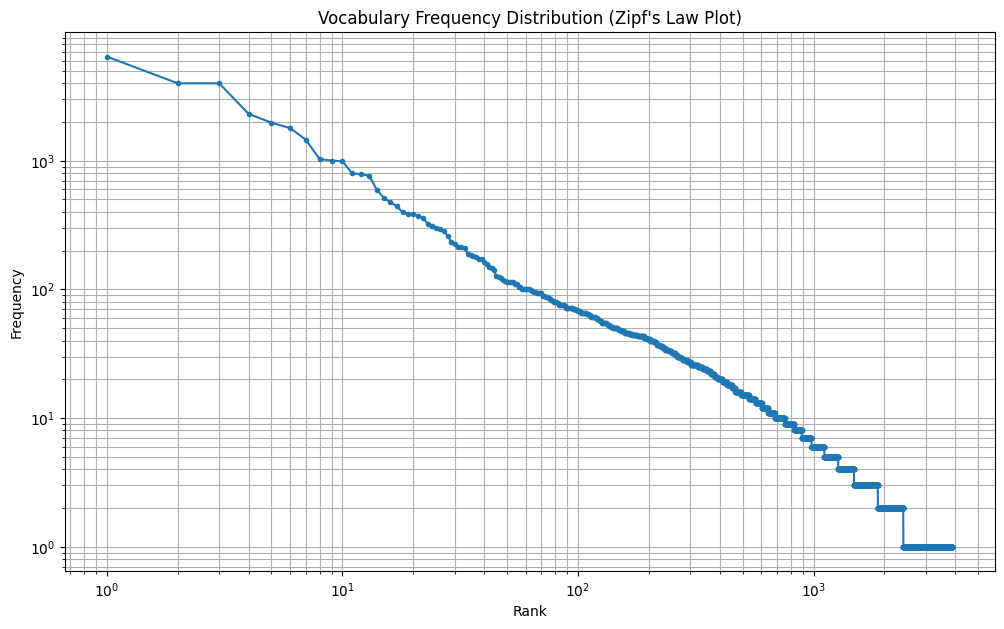

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Get word frequencies and sort them for ranking
word_frequencies = sorted([count for word, count in fdist.items()], reverse=True)
word_ranks = np.arange(1, len(word_frequencies) + 1)

plt.figure(figsize=(12, 7))
plt.loglog(word_ranks, word_frequencies, marker='.', linestyle='-')
plt.title('Vocabulary Frequency Distribution (Zipf\'s Law Plot)')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.grid(True, which="both", ls="-")
plt.show()


#### 3. Vocabulary vs Corpus Size (Type-Token Curve)

This plot illustrates how the vocabulary size grows as more tokens are encountered in the corpus. It helps understand the rate at which new words are introduced into the text.

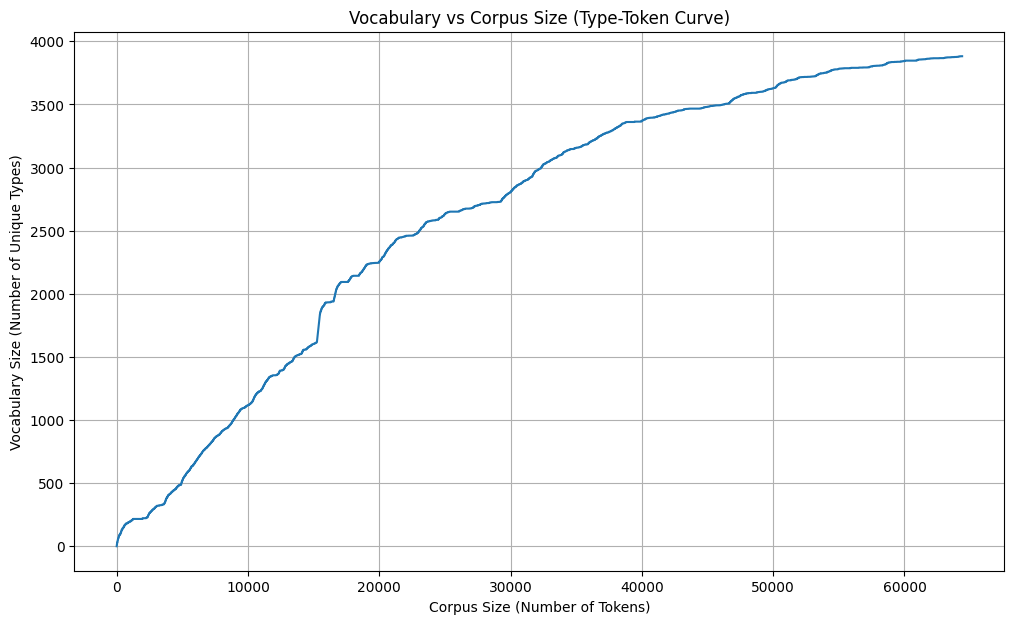

In [18]:
import matplotlib.pyplot as plt

# Calculate Type-Token Curve
seen_tokens = set()
types_count = []
tokens_count = []

for i, token in enumerate(all_tokens):
    seen_tokens.add(token)
    types_count.append(len(seen_tokens))
    tokens_count.append(i + 1)

plt.figure(figsize=(12, 7))
plt.plot(tokens_count, types_count)
plt.title('Vocabulary vs Corpus Size (Type-Token Curve)')
plt.xlabel('Corpus Size (Number of Tokens)')
plt.ylabel('Vocabulary Size (Number of Unique Types)')
plt.grid(True)
plt.show()


## D. Character Distribution

This section analyzes the distribution of different character types (alphabetic, numeric, spaces, punctuation, etc.) within the dataset. Understanding this distribution can provide insights into the nature of the text, potential noise, or specific language characteristics.


In [19]:
import collections
import string

# Initialize counters for different character types
char_counts = collections.defaultdict(int)
total_chars = 0

# Define emoji and special character ranges/sets
# This is a basic approach and might not catch all unicode special characters/emojis
emoji_ranges = [
    (0x1F600, 0x1F64F),  # Emoticons
    (0x1F300, 0x1F5FF),  # Miscellaneous Symbols and Pictographs
    (0x1F680, 0x1F6FF),  # Transport and Map Symbols
    (0x1F1E0, 0x1F1FF),  # Regional Indicator Symbols
    (0x2600, 0x26FF),    # Miscellaneous Symbols
    (0x2700, 0x27BF)     # Dingbats
]

def is_emoji(char):
    char_code = ord(char)
    for start, end in emoji_ranges:
        if start <= char_code <= end:
            return True
    return False


# Iterate through each text and categorize its characters
for text in df_cleaned['text']:
    for char in text:
        total_chars += 1
        if char.isalpha():
            char_counts['Alphabetic'] += 1
        elif char.isdigit():
            char_counts['Numbers'] += 1
        elif char.isspace():
            char_counts['Spaces'] += 1
        elif char in string.punctuation:
            char_counts['Punctuation'] += 1
        elif is_emoji(char):
            char_counts['Emojis'] += 1
        else:
            char_counts['Other Characters'] += 1

# Calculate percentages
char_percentages = {category: (count / total_chars) * 100 for category, count in char_counts.items()}

# Convert to DataFrame for display and plotting
df_char_dist = pd.DataFrame(char_percentages.items(), columns=['Character Type', 'Percentage'])
df_char_dist = df_char_dist.sort_values(by='Percentage', ascending=False).reset_index(drop=True)

display(df_char_dist.round(2))


,Character Type,Percentage
0,Alphabetic,78.43
1,Spaces,14.57
2,Punctuation,6.69
3,Emojis,0.18
4,Numbers,0.10
5,Other Characters,0.03


### Character-Category Bar Chart

This bar chart visualizes the distribution of different character types, making it easy to compare their proportions within the dataset. As requested, a bar chart is preferred for clear comparison of percentages.

/tmp/ipykernel_4673/3347056095.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentage', y='Character Type', data=df_char_dist, palette='viridis')


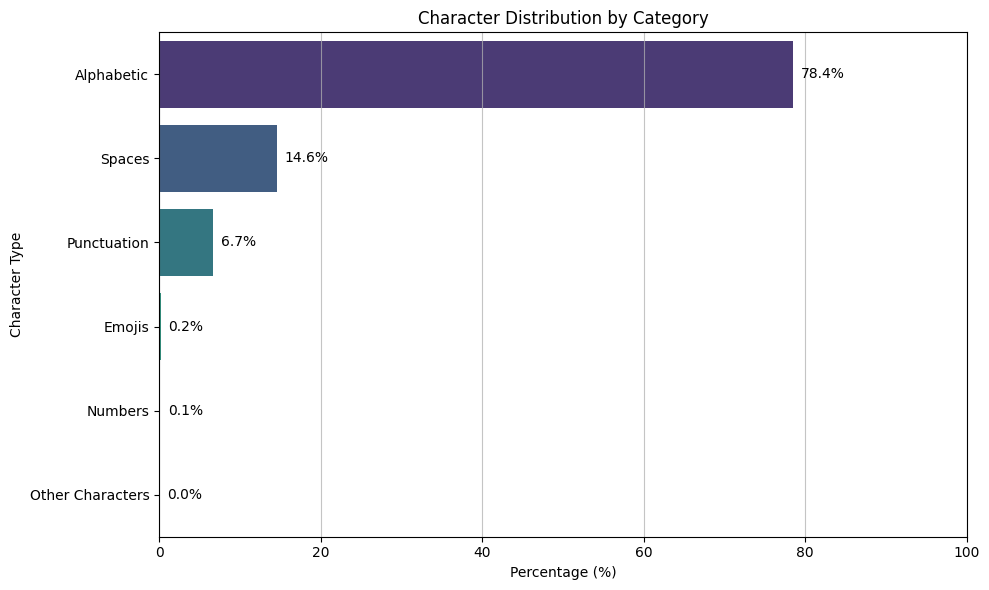

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Percentage', y='Character Type', data=df_char_dist, palette='viridis')
plt.title('Character Distribution by Category')
plt.xlabel('Percentage (%)')
plt.ylabel('Character Type')
plt.xlim(0, 100) # Ensure x-axis goes from 0 to 100

# Add percentages to the bars
for index, row in df_char_dist.iterrows():
    plt.text(row.Percentage + 1, index, f'{row.Percentage:.1f}%', color='black', ha="left", va="center")

plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()


## F. Character n-gram Distribution

This section analyzes the distribution of character n-grams (sequences of n characters) within the dataset. Understanding these patterns can be crucial for tasks like spell-checking, text generation, or in this case, developing a Romanized Pashto character n-gram selector.

In [21]:
import collections
import matplotlib.pyplot as plt
import seaborn as sns

# Combine all text into a single string for n-gram analysis
all_text = ' '.join(df_cleaned['text'].tolist())

def generate_ngrams(text, n):
    """Generates character n-grams from a given text."""
    text = text.lower() # Convert to lowercase for consistent counting
    ngrams = []
    for i in range(len(text) - n + 1):
        ngrams.append(text[i:i+n])
    return ngrams

# Calculate n-grams for different lengths
char_bigrams = generate_ngrams(all_text, 2)
char_trigrams = generate_ngrams(all_text, 3)
char_4grams = generate_ngrams(all_text, 4)
char_5grams = generate_ngrams(all_text, 5)

# Calculate frequency distributions
bigram_freq = collections.Counter(char_bigrams)
trigram_freq = collections.Counter(char_trigrams)
fourgram_freq = collections.Counter(char_4grams)
fivegram_freq = collections.Counter(char_5grams)

print("--- Character n-gram Statistics ---")
print(f"Total unique bigrams: {len(bigram_freq)}")
print(f"Total unique trigrams: {len(trigram_freq)}")
print(f"Total unique 4-grams: {len(fourgram_freq)}")
print(f"Total unique 5-grams: {len(fivegram_freq)}")

print("\n--- Top 20 Character Bigrams ---")
display(pd.DataFrame(bigram_freq.most_common(20), columns=['Bigram', 'Frequency']))

print("\n--- Top 20 Character Trigrams ---")
display(pd.DataFrame(trigram_freq.most_common(20), columns=['Trigram', 'Frequency']))

print("\n--- Top 20 Character 4-grams ---")
display(pd.DataFrame(fourgram_freq.most_common(20), columns=['4-gram', 'Frequency']))

print("\n--- Top 20 Character 5-grams ---")
display(pd.DataFrame(fivegram_freq.most_common(20), columns=['5-gram', 'Frequency']))


--- Character n-gram Statistics ---
Total unique bigrams: 1243
Total unique trigrams: 5795
Total unique 4-grams: 17052
Total unique 5-grams: 33626

--- Top 20 Character Bigrams ---


,Bigram,Frequency
0,a,11718
1,k,7382
2,e,6037
3,wa,4486
4,w,4428
5,s,4312
6,ra,4115
7,d,4101
8,ar,4034
9,"""",3989



--- Top 20 Character Trigrams ---


,Trigram,Frequency
0,".""",3988
1,""" """,3987
2,kh,2693
3,pa,2646
4,pa,2362
5,wa,2296
6,a k,2095
7,ke,2001
8,de,1864
9,da,1838



--- Top 20 Character 4-grams ---


,4-gram,Frequency
0,"."" """,3987
1,pa,2269
2,"o.""",1829
3,ke,1775
4,"a.""",1430
5,da,1113
6,a kh,1068
7,wo.,1056
8,na,911
9,der,890



--- Top 20 Character 5-grams ---


,5-gram,Frequency
0,"o."" """,1829
1,"a."" """,1430
2,kho,775
3,"."" ""d",737
4,"wa.""",697
5,"wo.""",658
6,"wo.""",583
7,"ho.""",573
8,"sho.""",572
9,sho.,570


### Top-20 Character Bigrams Bar Chart

This chart visualizes the 20 most frequent character bigrams, providing insight into common character pairs in the dataset.

/tmp/ipykernel_4673/408893916.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


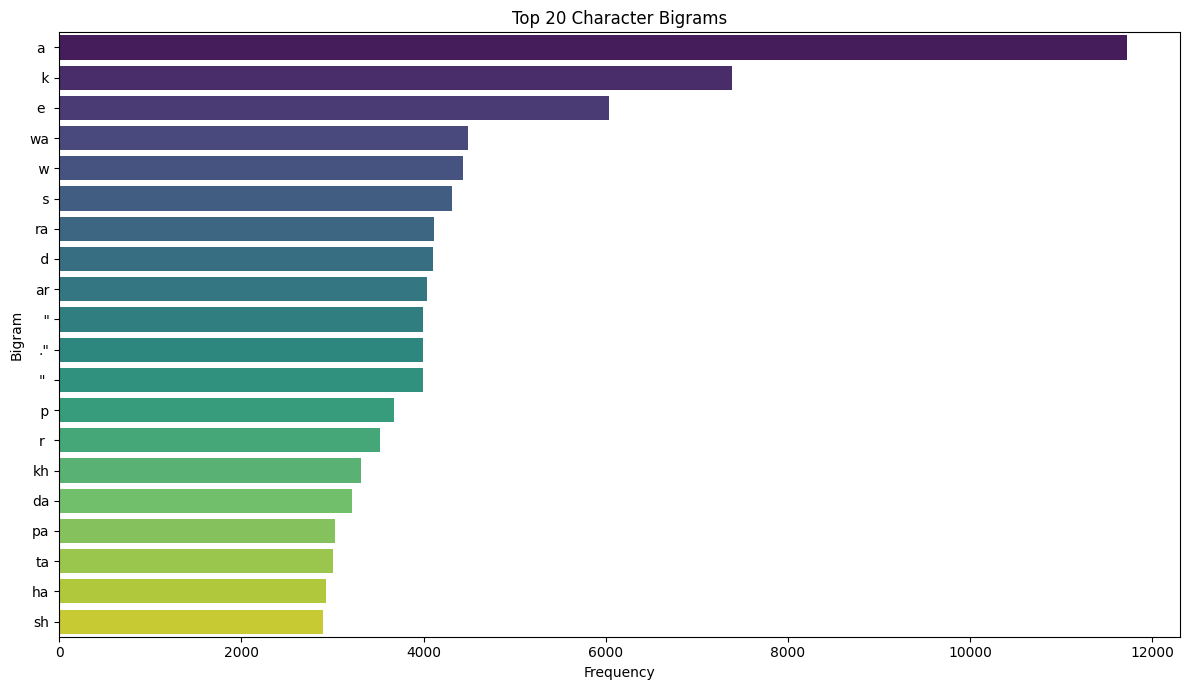

In [22]:
# Prepare data for the bar chart
bigrams_to_plot = bigram_freq.most_common(20)
words = [item[0] for item in bigrams_to_plot]
counts = [item[1] for item in bigrams_to_plot]

plt.figure(figsize=(12, 7))
sns.barplot(x=counts, y=words, palette='viridis')
plt.title('Top 20 Character Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

### Top-20 Character Trigrams Bar Chart

This chart visualizes the 20 most frequent character trigrams, highlighting common three-character sequences in the dataset.

/tmp/ipykernel_4673/1938933123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


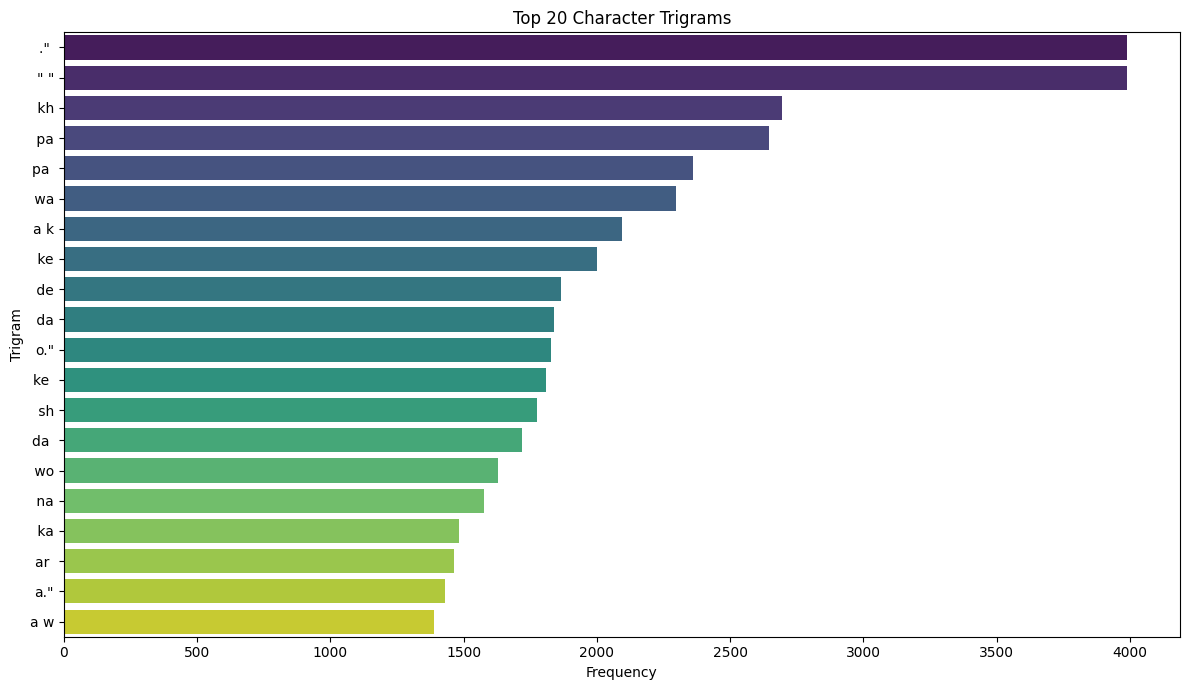

In [23]:
# Prepare data for the bar chart
trigrams_to_plot = trigram_freq.most_common(20)
words = [item[0] for item in trigrams_to_plot]
counts = [item[1] for item in trigrams_to_plot]

plt.figure(figsize=(12, 7))
sns.barplot(x=counts, y=words, palette='viridis')
plt.title('Top 20 Character Trigrams')
plt.xlabel('Frequency')
plt.ylabel('Trigram')
plt.tight_layout()
plt.show()

## G. Spelling Variation

This section focuses on automatically identifying potential spelling variants within the dataset using various similarity metrics. The goal is to generate candidate variant groups that can then be manually validated by a Pashto speaker to confirm if they represent the same word or meaning. We will also visualize the distribution of variants.

We will use:
*   **Edit Distance (Levenshtein):** Measures the minimum number of single-character edits (insertions, deletions, substitutions) required to change one word into the other.
*   **Character n-gram Similarity (Jaccard):** Measures the overlap between character n-grams of two words. (For this analysis, we will use trigrams for `n`).

**Note on Phonetic Similarity:** Implementing robust phonetic similarity for Romanized Pashto is a complex task requiring language-specific phonetic rules. For this general analysis, we will focus on the more universally applicable edit distance and character n-gram similarities. The generated candidates serve as a starting point for manual linguistic validation.

In [24]:
# Install python-Levenshtein for efficient edit distance calculation
%pip install python-Levenshtein --quiet

import Levenshtein
import collections
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.util import ngrams

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 62.4 MB/s eta 0:00:00


In [25]:
def calculate_levenshtein_distance(s1, s2):
    """Calculates the Levenshtein distance between two strings."""
    return Levenshtein.distance(s1, s2)

def calculate_jaccard_similarity_char_ngrams(s1, s2, n=3):
    """Calculates Jaccard similarity based on character n-grams."""
    if not s1 or not s2:
        return 0.0

    set1 = set(ngrams(s1, n))
    set2 = set(ngrams(s2, n))

    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))

    return intersection / union if union > 0 else 0.0

In [26]:
# Get the unique vocabulary from all_tokens (already lowercase from previous analysis)
unique_words = sorted(list(set(all_tokens)))

# Initialize a dictionary to store candidate variants for each word
word_to_variants = collections.defaultdict(set)

# Define similarity thresholds
levenshtein_threshold = 2  # Words with edit distance <= 2 are potential variants
jaccard_threshold = 0.6    # Words with Jaccard similarity >= 0.6 (on char trigrams) are potential variants

print(f"Detecting candidate spelling variants... (Vocabulary size: {len(unique_words)})")

# Iterate through unique words and find potential variants
# Using itertools.combinations for efficient pairwise comparison without duplicates
for word1, word2 in itertools.combinations(unique_words, 2):
    # Levenshtein Distance
    if calculate_levenshtein_distance(word1, word2) <= levenshtein_threshold:
        word_to_variants[word1].add(word2)
        word_to_variants[word2].add(word1)

    # Jaccard Similarity (character trigrams)
    if calculate_jaccard_similarity_char_ngrams(word1, word2, n=3) >= jaccard_threshold:
        word_to_variants[word1].add(word2)
        word_to_variants[word2].add(word1)

# Convert sets to lists and filter out empty variant lists
# Also, ensure words are not considered variants of themselves in the count
final_variant_groups = {word: sorted(list(variants - {word})) for word, variants in word_to_variants.items() if len(variants - {word}) > 0}

print(f"\nFound {len(final_variant_groups)} words with potential spelling variants.")

print("\n--- Examples of Candidate Variant Groups ---")
# Display some examples
example_count = 0
for word, variants in final_variant_groups.items():
    if example_count < 10:
        print(f"'{word}': {variants}")
        example_count += 1
    else:
        break

Detecting candidate spelling variants... (Vocabulary size: 3882)

Found 3099 words with potential spelling variants.

--- Examples of Candidate Variant Groups ---
'!': ['#', '%', "''", ',', '.', '0', '1', '10', '12', '15', '2', '20', '22', '24', '25', '3', '30', '4', '40', '42', '45', '5', '50', '6', '60', '70', '8', '9', '90', '95', ':', '?', '@', '``', 'ac', 'af', 'ai', 'aj', 'al', 'ao', 'au', 'ba', 'be', 'da', 'de', 'di', 'do', 'e', 'f1', 'fr', 'gi', 'ho', 'id', 'it', 'ka', 'ke', 'kg', 'km', 'la', 'le', 'ma', 'mb', 'me', 'mo', 'my', 'na', 'ne', 'no', 'nu', 'o', 'of', 'ok', 'on', 'or', 'os', 'pa', 'ra', 'ro', 'sa', 'se', 'so', 'ta', 'to', 'tv', 'wa', 'we', 'wi', 'wo', 'ya', 'ye', 'yo', 'za', 'zi', 'zu', '⏳', '☕', '☕📖', '☹️', '☺️', '✍️', '❌', '❌🚫', '❤️', '➡️', '🌟', '🌟😁', '🌤️', '🌹', '🌹💐', '🍵', '🎉', '🎉🎉', '🎉👏', '🎧', '🎧😴', '👀', '👋', '👌', '👌😎', '👍', '👍👍', '👎', '👎👎', '👎😠', '👏', '💀', '💔', '💔💔', '💔😞', '💖', '💢😤', '💪', '💪👏', '💭', '💯', '💯🔥', '📅', '📌', '📌🕐', '📍', '📖', '📝', '📞', '📞📅', '📷', '🔄', '

### Graph: Number of spelling variants per word

This bar chart illustrates the distribution of words based on how many potential spelling variants they have. This helps in understanding the extent of spelling variations within the dataset.

/tmp/ipykernel_4673/1007370910.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Number of Words', y='Number of Variants', data=df_variant_distribution.head(10), palette='viridis') # Limiting to top 10 for better visualization


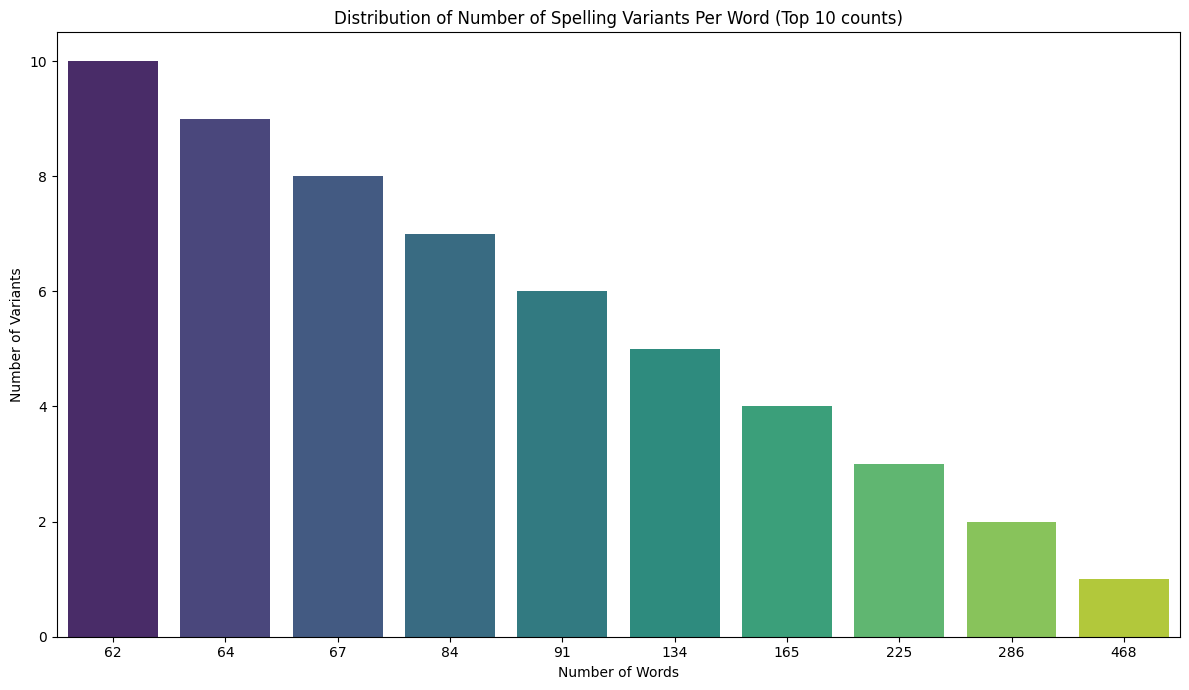


--- Detailed Distribution of Number of Variants ---


,Number of Variants,Number of Words
0,1,468
1,2,286
2,3,225
3,4,165
4,5,134
5,6,91
6,7,84
7,8,67
8,9,64
9,10,62


In [27]:
# Calculate the number of variants for each word
num_variants_per_word = {word: len(variants) for word, variants in final_variant_groups.items()}

# Create a Series and get the value counts of variant numbers
variant_counts_distribution = pd.Series(num_variants_per_word).value_counts().sort_index()

# Convert to DataFrame for plotting
df_variant_distribution = variant_counts_distribution.reset_index()
df_variant_distribution.columns = ['Number of Variants', 'Number of Words']

plt.figure(figsize=(12, 7))
sns.barplot(x='Number of Words', y='Number of Variants', data=df_variant_distribution.head(10), palette='viridis') # Limiting to top 10 for better visualization
plt.title('Distribution of Number of Spelling Variants Per Word (Top 10 counts)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Variants')
plt.tight_layout()
plt.show()

print("\n--- Detailed Distribution of Number of Variants ---")
display(df_variant_distribution.head(10).round(0))

### Graph: Most Frequently Varying Words

This bar chart highlights the top words that have the most potential spelling variants, indicating areas where standardization or further linguistic analysis might be most beneficial.

/tmp/ipykernel_4673/588741343.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='magma')


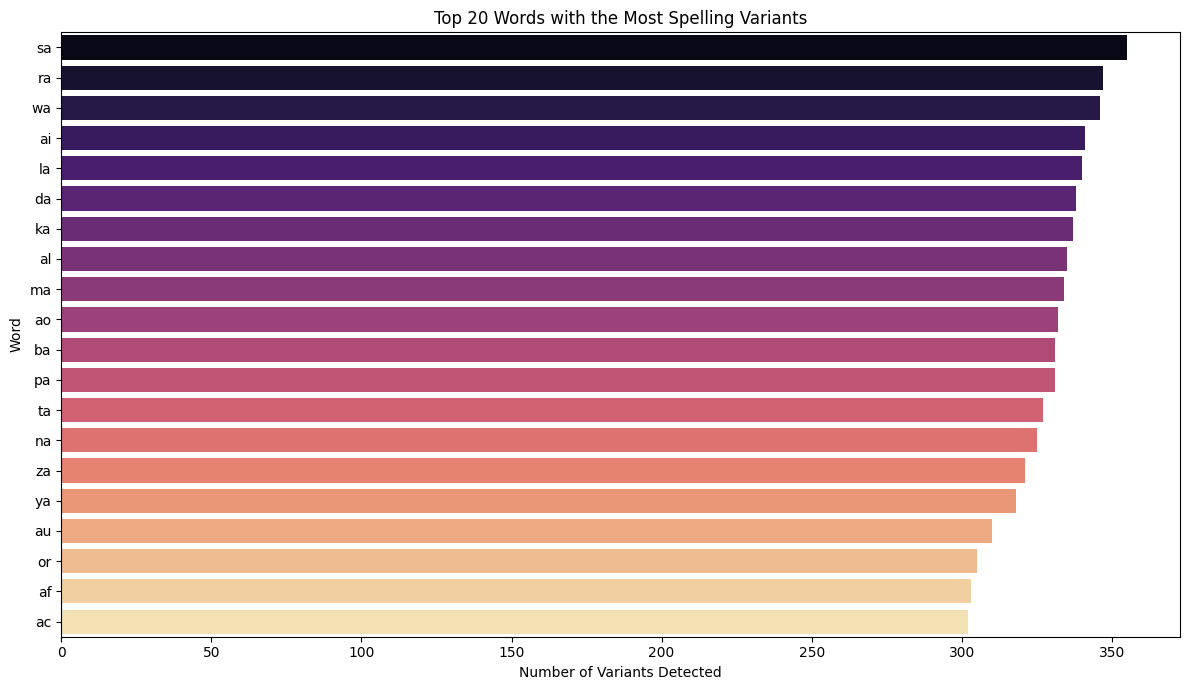

In [28]:
# Sort words by the number of variants in descending order
most_varying_words = sorted(num_variants_per_word.items(), key=lambda item: item[1], reverse=True)

# Get the top 20 most frequently varying words
top_20_varying_words = most_varying_words[:20]

# Prepare data for the bar chart
words = [item[0] for item in top_20_varying_words]
counts = [item[1] for item in top_20_varying_words]

plt.figure(figsize=(12, 7))
sns.barplot(x=counts, y=words, palette='magma')
plt.title('Top 20 Words with the Most Spelling Variants')
plt.xlabel('Number of Variants Detected')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

## H. Repeated-Character Patterns

This section analyzes the prevalence and characteristics of repeated-character patterns within the dataset. Such patterns are common in informal text, like WhatsApp messages, and can provide insights into the communication style and potential need for normalization.

In [29]:
import re
import pandas as pd
import collections
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_repeated_characters(df, text_column='text', min_repetition_length=2):
    """
    Analyzes repeated character patterns in a DataFrame's text column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        text_column (str): The name of the column containing text data.
        min_repetition_length (int): Minimum number of repetitions to consider (e.g., 2 for 'aa', 3 for 'aaa').

    Returns:
        tuple: A tuple containing:
            - int: Number of sentences with repeated characters.
            - list: List of dictionaries, each containing 'word', 'pattern', and 'length' of repetitions.
            - dict: Counts of repetition lengths.
            - collections.Counter: Most common repeated character sequences.
    """
    sentences_with_repeated_chars = 0
    all_repeated_patterns = []
    repetition_lengths = collections.defaultdict(int)
    repeated_seq_counts = collections.Counter()

    for text in df[text_column]:
        found_in_sentence = False
        # Regex to find any character repeated min_repetition_length or more times
        # \b ensures we're looking at whole words or distinct sequences
        # (\w) captures the character, \1+ matches one or more of the captured character
        # We need to find sequences of the same character repeating
        matches = re.finditer(r'(\w)(\1{' + str(min_repetition_length - 1) + ',})', text, re.IGNORECASE)

        for match in matches:
            found_in_sentence = True
            repeated_char = match.group(1).lower()
            full_repetition = match.group(0).lower()
            actual_length = len(full_repetition)

            # Store details for each detected repetition
            all_repeated_patterns.append({
                'word': full_repetition, # The full sequence like 'aaaa'
                'pattern': repeated_char, # The repeating char like 'a'
                'length': actual_length
            })
            repetition_lengths[actual_length] += 1
            repeated_seq_counts[full_repetition] += 1

        if found_in_sentence:
            sentences_with_repeated_chars += 1

    return sentences_with_repeated_chars, all_repeated_patterns, repetition_lengths, repeated_seq_counts

# Perform the analysis
sentences_with_rep_chars, all_rep_patterns_details, rep_lengths_dist, most_common_rep_sequences = \
    analyze_repeated_characters(df_cleaned, text_column='text', min_repetition_length=2)

# --- Display Results ---

print("--- Repeated-Character Patterns Analysis ---")
print(f"Number of sentences containing repeated characters: {sentences_with_rep_chars}")

# Calculate words with 2+ and 3+ repetitions
words_with_2plus_reps = len([p for p in all_rep_patterns_details if p['length'] >= 2])
words_with_3plus_reps = len([p for p in all_rep_patterns_details if p['length'] >= 3])

print(f"Number of words (sequences) with 2+ repetitions: {words_with_2plus_reps}")
print(f"Number of words (sequences) with 3+ repetitions: {words_with_3plus_reps}")

max_repetition = max(rep_lengths_dist.keys()) if rep_lengths_dist else 0
print(f"Maximum repetition length found: {max_repetition}")

print("\n--- Most Common Repeated-Character Sequences (Top 10) ---")
display(pd.DataFrame(most_common_rep_sequences.most_common(10), columns=['Sequence', 'Frequency']))

--- Repeated-Character Patterns Analysis ---
Number of sentences containing repeated characters: 3389
Number of words (sequences) with 2+ repetitions: 4264
Number of words (sequences) with 3+ repetitions: 275
Maximum repetition length found: 6

--- Most Common Repeated-Character Sequences (Top 10) ---


,Sequence,Frequency
0,ee,728
1,oo,626
2,aa,566
3,ss,444
4,pp,382
5,ll,261
6,ff,225
7,tt,225
8,aaa,116
9,cc,75


### Graph: Repetition-Length Distribution

This bar chart visualizes the distribution of repetition lengths found in the dataset, showing how many times a character was repeated consecutively. This helps in understanding the common patterns of character elongation.

/tmp/ipykernel_4673/1898167551.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Repetition Length', y='Count', data=df_rep_lengths, palette='viridis')


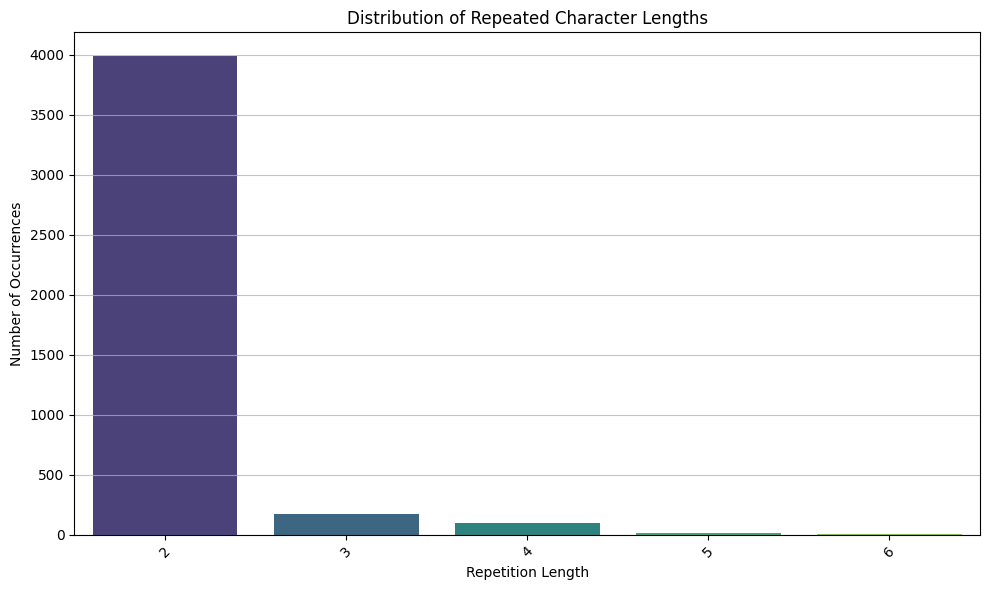

In [30]:
# Convert repetition_lengths dictionary to a DataFrame for plotting
df_rep_lengths = pd.DataFrame(rep_lengths_dist.items(), columns=['Repetition Length', 'Count'])
df_rep_lengths = df_rep_lengths.sort_values(by='Repetition Length').reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Repetition Length', y='Count', data=df_rep_lengths, palette='viridis')
plt.title('Distribution of Repeated Character Lengths')
plt.xlabel('Repetition Length')
plt.ylabel('Number of Occurrences')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## I. Punctuation Patterns

This section analyzes the use of punctuation within the dataset. Understanding punctuation patterns can reveal insights into the conversational style, sentence structure, and overall formality (or informality) of the text, particularly relevant for informal communication like WhatsApp messages.

In [31]:
import re
import pandas as pd
import collections
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_punctuation_patterns(df, text_column='text'):
    """
    Analyzes punctuation patterns in a DataFrame's text column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        text_column (str): The name of the column containing text data.

    Returns:
        tuple: A tuple containing:
            - dict: Percentages of sentences with specific punctuation characteristics.
            - collections.Counter: Most common punctuation patterns.
    """
    total_sentences = len(df)
    stats = {}
    all_punctuation_patterns = []

    # Convert text column to string type to avoid errors with non-string entries
    df[text_column] = df[text_column].astype(str)

    # Percentage with no punctuation
    no_punct_count = df[text_column].apply(lambda x: not any(char in '"#$%&\'()*+,-./:;<=>?@[\]^_`{|}~' for char in x)).sum()
    stats['no_punctuation'] = (no_punct_count / total_sentences) * 100

    # Specific punctuation marks
    specific_punctuations = ['.', ',', '!', '?', '...']
    for punct in specific_punctuations:
        count = df[text_column].apply(lambda x: punct in x).sum()
        stats[punct] = (count / total_sentences) * 100

    # Specific punctuation patterns
    pattern_punctuations = ['?!', '!!!', '???']
    for pattern in pattern_punctuations:
        # Use regex to find the exact pattern
        count = df[text_column].apply(lambda x: bool(re.search(re.escape(pattern), x))).sum()
        stats[pattern] = (count / total_sentences) * 100

    # Extract all punctuation patterns for frequency count
    for text in df[text_column]:
        # Find sequences of punctuation marks
        matches = re.findall(r'[.,!?;:\-\/_"#$%&\'()*+<=>@\[\]^`{|}~]{1,}', text)
        all_punctuation_patterns.extend(matches)

    most_common_patterns = collections.Counter(all_punctuation_patterns)

    return stats, most_common_patterns

# Perform the analysis
punctuation_stats, most_common_punct_patterns = analyze_punctuation_patterns(df_cleaned, text_column='text')

print("--- Punctuation Patterns Analysis ---")
print("Percentage of sentences containing:")
for key, value in punctuation_stats.items():
    print(f"- {key.replace('_', ' ').capitalize()}: {value:.2f}%")

print("\n--- Most Common Punctuation Patterns (Top 10) ---")
display(pd.DataFrame(most_common_punct_patterns.most_common(10), columns=['Pattern', 'Frequency']))

--- Punctuation Patterns Analysis ---
Percentage of sentences containing:
- No punctuation: 9.26%
- .: 79.60%
- ,: 11.45%
- !: 2.63%
- ?: 8.07%
- ...: 1.20%
- ?!: 0.01%
- !!!: 0.72%
- ???: 0.49%

--- Most Common Punctuation Patterns (Top 10) ---


<>:28: SyntaxWarning: invalid escape sequence '\]'
<>:28: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_4673/2456867553.py:28: SyntaxWarning: invalid escape sequence '\]'
  no_punct_count = df[text_column].apply(lambda x: not any(char in '"#$%&\'()*+,-./:;<=>?@[\]^_`{|}~' for char in x)).sum()


,Pattern,Frequency
0,"""",3989
1,".""",3989
2,.,2645
3,",",1028
4,?,623
5,/,188
6,!,159
7,#,100
8,://,100
9,@,100


### Graph: Top Punctuation Patterns

This bar chart visualizes the most frequently occurring punctuation patterns, providing a quick overview of common conversational cues and stylistic elements within the corpus. This helps in characterizing the informal/WhatsApp nature of the corpus.

/tmp/ipykernel_4673/1020831556.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=patterns, palette='cubehelix')


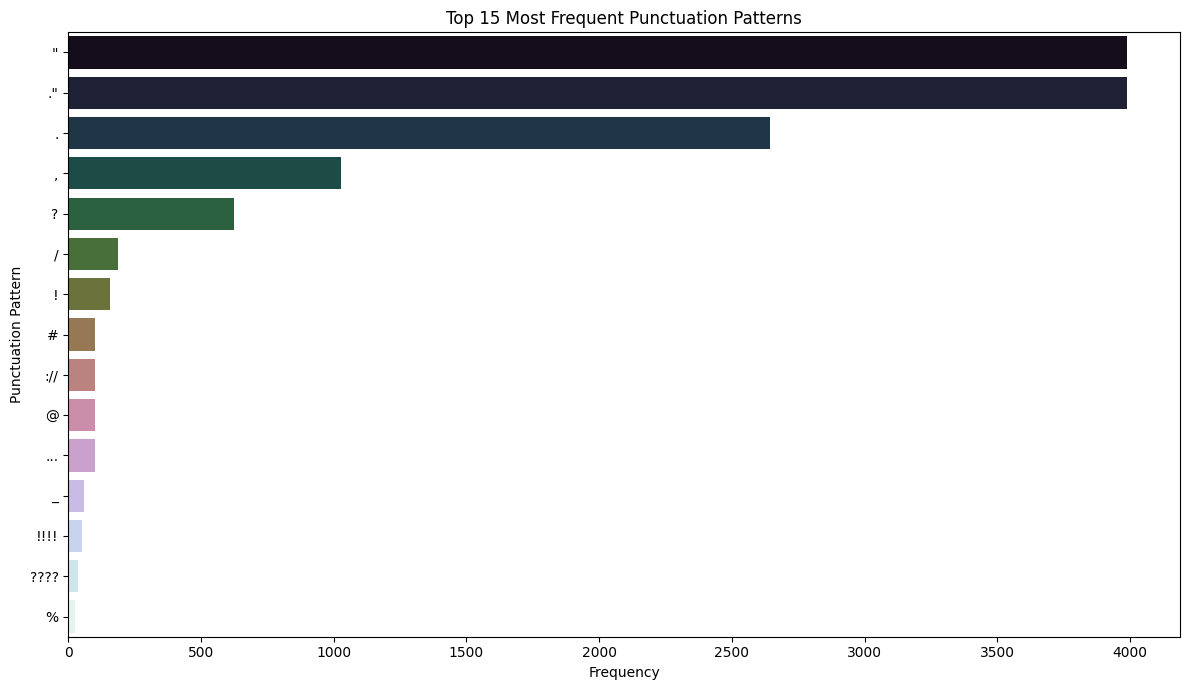

In [32]:
# Prepare data for the bar chart
punct_to_plot = most_common_punct_patterns.most_common(15) # Limiting to top 15 for readability
patterns = [item[0] for item in punct_to_plot]
counts = [item[1] for item in punct_to_plot]

plt.figure(figsize=(12, 7))
sns.barplot(x=counts, y=patterns, palette='cubehelix')
plt.title('Top 15 Most Frequent Punctuation Patterns')
plt.xlabel('Frequency')
plt.ylabel('Punctuation Pattern')
plt.tight_layout()
plt.show()

## J. Emoji Analysis

This section analyzes the use of emojis within the dataset. As emojis are a common feature of informal and social media communication, their analysis can provide valuable insights into the expressiveness and conversational style of the corpus, especially if it represents WhatsApp/social-media language.

In [33]:
import re
import collections
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse the is_emoji function defined previously
# (Assuming `emoji_ranges` is still in scope from section E)
def is_emoji(char):
    char_code = ord(char)
    for start, end in emoji_ranges:
        if start <= char_code <= end:
            return True
    return False

def analyze_emojis(df, text_column='text'):
    """
    Analyzes emoji patterns in a DataFrame's text column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        text_column (str): The name of the column containing text data.

    Returns:
        dict: A dictionary containing various emoji statistics and patterns.
    """
    total_sentences = len(df)
    sentences_with_emojis_count = 0
    all_emojis = []
    emojis_per_sentence_counts = []
    multiple_emoji_sequences = collections.Counter()

    for text in df[text_column]:
        emojis_in_text = []
        for char in text:
            if is_emoji(char):
                emojis_in_text.append(char)

        if emojis_in_text:
            sentences_with_emojis_count += 1
            all_emojis.extend(emojis_in_text)
            emojis_per_sentence_counts.append(len(emojis_in_text))

            # Check for multiple-emoji sequences
            if len(emojis_in_text) > 1:
                # Join consecutive emojis to form sequences
                current_sequence = ''
                for char in text:
                    if is_emoji(char):
                        current_sequence += char
                    else:
                        if len(current_sequence) > 1:
                            multiple_emoji_sequences[current_sequence] += 1
                        current_sequence = ''
                # After loop, check if there's a pending sequence
                if len(current_sequence) > 1:
                    multiple_emoji_sequences[current_sequence] += 1

    # Calculate statistics
    unique_emojis = sorted(list(set(all_emojis)))
    emoji_frequency = collections.Counter(all_emojis)

    avg_emojis_per_sentence = sum(emojis_per_sentence_counts) / sentences_with_emojis_count if sentences_with_emojis_count > 0 else 0
    max_emojis_in_sentence = max(emojis_per_sentence_counts) if emojis_per_sentence_counts else 0

    stats = {
        'total_sentences': total_sentences,
        'sentences_with_emojis_count': sentences_with_emojis_count,
        'percentage_sentences_with_emojis': (sentences_with_emojis_count / total_sentences) * 100 if total_sentences > 0 else 0,
        'unique_emojis_count': len(unique_emojis),
        'total_emojis_found': len(all_emojis),
        'most_common_emojis': emoji_frequency.most_common(10),
        'avg_emojis_per_sentence_with_emojis': avg_emojis_per_sentence,
        'max_emojis_in_single_sentence': max_emojis_in_sentence,
        'most_common_multiple_emoji_sequences': multiple_emoji_sequences.most_common(5) # Top 5 sequences
    }

    return stats

# Perform emoji analysis
emoji_analysis_results = analyze_emojis(df_cleaned, text_column='text')

print("--- Emoji Analysis ---")
print(f"Percentage of sentences containing emojis: {emoji_analysis_results['percentage_sentences_with_emojis']:.2f}%")
print(f"Number of unique emojis found: {emoji_analysis_results['unique_emojis_count']}")
print(f"Total emojis found: {emoji_analysis_results['total_emojis_found']}")
print(f"Average emojis per sentence (only sentences with emojis): {emoji_analysis_results['avg_emojis_per_sentence_with_emojis']:.2f}")
print(f"Maximum emojis in a single sentence: {emoji_analysis_results['max_emojis_in_single_sentence']}")

print("\n--- Most Common Emojis (Top 10) ---")
display(pd.DataFrame(emoji_analysis_results['most_common_emojis'], columns=['Emoji', 'Frequency']))

if emoji_analysis_results['most_common_multiple_emoji_sequences']:
    print("\n--- Most Common Multiple-Emoji Sequences (Top 5) ---")
    display(pd.DataFrame(emoji_analysis_results['most_common_multiple_emoji_sequences'], columns=['Sequence', 'Frequency']))
else:
    print("\nNo multiple-emoji sequences found.")

--- Emoji Analysis ---
Percentage of sentences containing emojis: 2.33%
Number of unique emojis found: 89
Total emojis found: 495
Average emojis per sentence (only sentences with emojis): 2.58
Maximum emojis in a single sentence: 8

--- Most Common Emojis (Top 10) ---


,Emoji,Frequency
0,😭,19
1,💔,18
2,😢,16
3,🔥,14
4,😍,13
5,😐,12
6,🎉,11
7,👏,11
8,😤,11
9,🕐,10



--- Most Common Multiple-Emoji Sequences (Top 5) ---


,Sequence,Frequency
0,😐🙂,2
1,😊👍,1
2,🔥💪,1
3,🎉👏,1
4,😄🙌,1


### Graph 1: Top-20 Emoji Frequency

This bar chart visualizes the 20 most frequently used emojis, providing insight into the most popular emotional and contextual cues used in the dataset.

/tmp/ipykernel_4673/1975204138.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=emojis, palette='plasma')
/tmp/ipykernel_4673/1975204138.py:12: UserWarning: Glyph 128148 (\N{BROKEN HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4673/1975204138.py:12: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4673/1975204138.py:12: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4673/1975204138.py:12: UserWarning: Glyph 128079 (\N{CLAPPING HANDS SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4673/1975204138.py:12: UserWarning: Glyph 128548 (\N{FACE WITH LOOK OF TRIUMPH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4673/197520

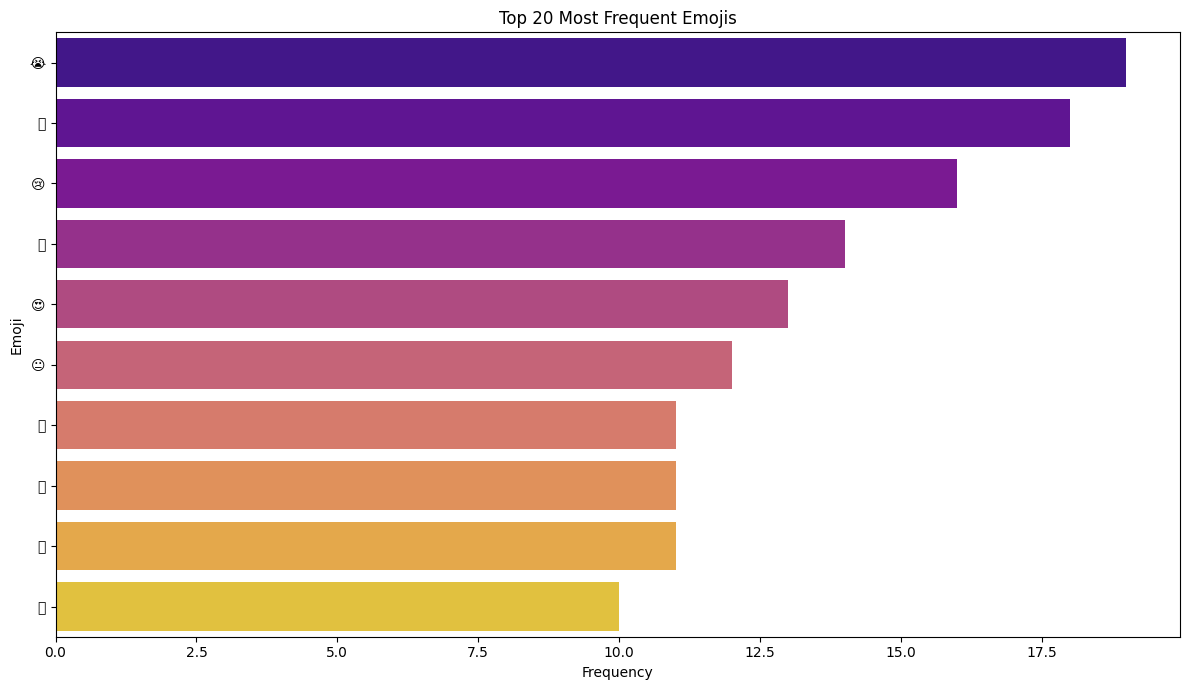

In [34]:
# Prepare data for the bar chart
emojis_to_plot = emoji_analysis_results['most_common_emojis'][:20]
if emojis_to_plot:
    emojis = [item[0] for item in emojis_to_plot]
    counts = [item[1] for item in emojis_to_plot]

    plt.figure(figsize=(12, 7))
    sns.barplot(x=counts, y=emojis, palette='plasma')
    plt.title('Top 20 Most Frequent Emojis')
    plt.xlabel('Frequency')
    plt.ylabel('Emoji')
    plt.tight_layout()
    plt.show()
else:
    print("No emojis found to plot.")

### Graph 2: Percentage of Sentences With/Without Emojis

This pie chart shows the proportion of sentences that contain emojis versus those that do not, offering a clear picture of the overall emoji usage rate in the corpus.

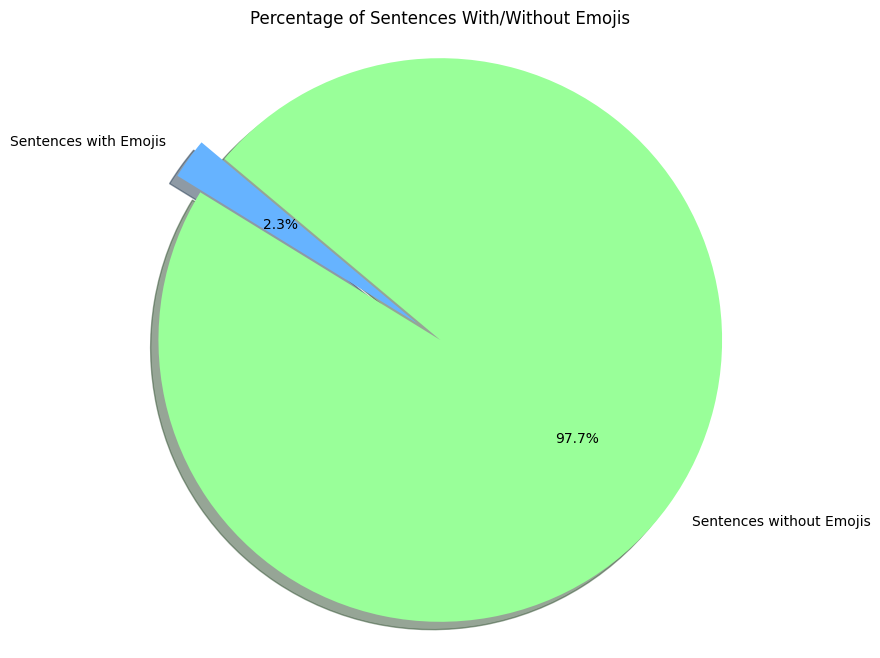

In [35]:
# Prepare data for the pie chart
percentage_with_emojis = emoji_analysis_results['percentage_sentences_with_emojis']
percentage_without_emojis = 100 - percentage_with_emojis

labels = ['Sentences with Emojis', 'Sentences without Emojis']
sizes = [percentage_with_emojis, percentage_without_emojis]
colors = ['#66b3ff', '#99ff99'] # Light blue and light green
explode = (0.1, 0)  # Explode the 'with emojis' slice

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of Sentences With/Without Emojis')
plt.show()

## K. Code-Mixing Analysis

This section aims to analyze code-mixing patterns within the dataset, specifically identifying the presence of English words in sentences. Understanding code-mixing is crucial for characterizing informal communication, especially in multilingual contexts like the one this Romanized Pashto corpus might represent.

**Methodology Note:**
Due to the challenges of reliably distinguishing between Romanized Pashto and Romanized Urdu (or other languages) using general-purpose NLP tools without specialized lexicons or models, we will simplify the categorization:

*   **Pashto + English**: Sentences where at least one English word is detected.
*   **Predominantly Pashto/Other**: Sentences where no English words are detected. This category will include sentences that are purely Pashto, as well as any sentences that might contain Urdu or other languages that could not be identified as English. We explicitly acknowledge that this is an estimation, and further manual linguistic analysis would be required for precise differentiation of Romanized Pashto and Urdu.

This approach aligns with the instruction to *estimate* the language composition and the caution against treating automatic detection as ground truth.

In [36]:
import nltk
from nltk.corpus import words, stopwords
import string
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import collections

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/words')
except LookupError:
    nltk.download('words', quiet=True)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

# Load English word list and stopwords for identification
english_words = set(words.words())
english_stopwords = set(stopwords.words('english'))

def is_english_word(word):
    """Checks if a word is likely an English word, excluding common stopwords."""
    word_lower = word.lower()
    # Remove punctuation for better matching
    word_clean = word_lower.strip(string.punctuation)
    # Consider a word English if it's in the English dictionary and not a common English stopword
    return word_clean in english_words and word_clean not in english_stopwords

def classify_sentence_language(tokenized_sentence):
    """Classifies a sentence as 'Pashto + English' or 'Predominantly Pashto/Other'."""
    has_english = False
    for token in tokenized_sentence:
        if is_english_word(token):
            has_english = True
            break

    if has_english:
        return 'Pashto + English'
    else:
        return 'Predominantly Pashto/Other'

# Apply the classification to each sentence
df_cleaned['language_category'] = df_cleaned['tokenized_text'].apply(classify_sentence_language)

# Calculate the distribution of language categories
lang_distribution = df_cleaned['language_category'].value_counts(normalize=True) * 100

print("--- Language Composition Analysis ---")
display(lang_distribution.to_frame().round(2))

# Store for potential further analysis or reporting
code_mixing_results = lang_distribution.to_dict()

--- Language Composition Analysis ---


,proportion
language_category,
Pashto + English,90.16
Predominantly Pashto/Other,9.84


### Language Composition Bar Chart

This bar chart visualizes the estimated language composition of the dataset based on the presence of English words. It provides an overview of code-mixing patterns.

/tmp/ipykernel_4673/188183474.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentage', y='Language Category', data=lang_df, palette='magma')


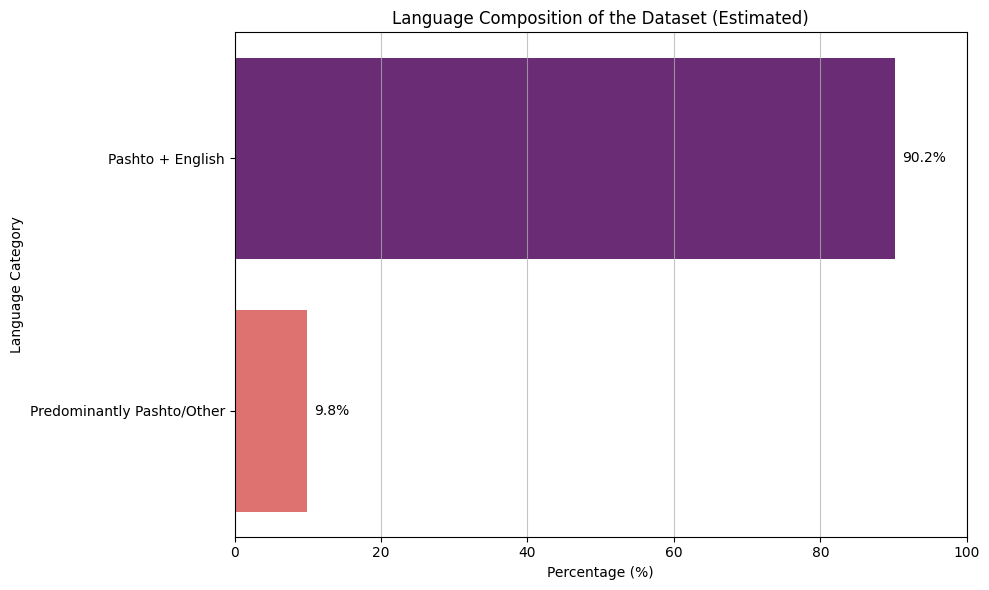

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
lang_df = lang_distribution.reset_index()
lang_df.columns = ['Language Category', 'Percentage']

plt.figure(figsize=(10, 6))
sns.barplot(x='Percentage', y='Language Category', data=lang_df, palette='magma')
plt.title('Language Composition of the Dataset (Estimated)')
plt.xlabel('Percentage (%)')
plt.ylabel('Language Category')
plt.xlim(0, 100) # Ensure x-axis goes from 0 to 100

# Add percentages to the bars
for index, row in lang_df.iterrows():
    plt.text(row.Percentage + 1, index, f'{row.Percentage:.1f}%', color='black', ha="left", va="center")

plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

# Dataset Findings Report for Romanized Pashto Corpus

This report summarizes the initial statistical and linguistic analysis conducted on the Romanized Pashto dataset. The findings are derived exclusively from the tests implemented in this notebook, with careful distinction between directly measured facts, their interpretations, and the inherent limitations of automated analysis.

## 1. DATASET OVERVIEW

This section presents the fundamental characteristics and quality aspects of the `df_cleaned` dataset after the initial cleaning process.

### Factual Findings:
*   **Total number of records/sentences**: 8239 (Original: 8239, Current: 8239)
*   **Number of columns**: 6 (original were 2: 'text', 'label'; additional columns 'tokenized_text', 'num_words', 'num_chars', 'language_category' have been added during analysis).
*   **Dataset structure**: Two primary columns, `text` (containing Romanized Pashto sentences) and `label` (numerical sentiment labels: 0, 1, 2).
*   **Missing values in 'text'**: 0 records (after cleaning).
*   **Empty records in 'text'**: 0 records (after cleaning).
*   **Non-string values in 'text'**: 0 records (after initial conversion to string).
*   **Leading/trailing whitespace in 'text'**: 0 records (after removal).
*   **Invalid/unexpected labels**: 0 records (after mapping 'Positive', 'Negative', 'Neutral' to 0, 1, 2 and removing any unmappable entries).
*   **Unique records (text content)**: 7095 (This is the number of distinct text entries in the dataset).
*   **Exact duplicate rows (text + label)**: 2015 records identified (24.46% of total rows). These are rows where both 'text' and 'label' are identical.
*   **Duplicate texts (regardless of label)**: 2029 records (24.63% of total rows) have duplicate 'text' content, spanning 885 unique text entries that appear more than once.

### Interpretation:
*   The dataset is well-structured and appears to be free from basic data quality issues such as missing text, empty strings, or invalid labels following the initial cleaning steps. This suggests a relatively clean base for linguistic analysis.
*   A significant number of exact duplicate rows (text + label) and duplicate texts (regardless of label) have been identified. This indicates redundancy in the dataset, which might need to be addressed depending on the analysis goals (e.g., removing duplicates to avoid bias in training models).
*   The conversion of categorical labels ('Positive', 'Negative', 'Neutral') to numerical (0, 1, 2) provides a standardized format suitable for machine learning models.

### Limitations:
*   The cleaning process primarily addressed structural and overt data quality issues. It did not involve deeper linguistic cleaning (e.g., correcting misspellings, normalizing slang, handling code-switching complexities beyond basic detection).
*   The 'label' column was processed, but the *quality* or *accuracy* of these labels was not assessed; it was assumed that the provided labels are correct.
*   The presence of numerous duplicate texts (even if labels sometimes differ, potentially indicating conflicting labels, though none were found in section H) suggests a need for careful consideration during model training to avoid overfitting to repeated examples.

## 2. SENTENCE-LENGTH CHARACTERISTICS

This section details the distribution of sentence lengths within the dataset, measured by both words and characters.

### Factual Findings:

**Words per Sentence Statistics:**
*   **Count**: 8239 sentences
*   **Mean**: 7.82 words
*   **Median**: 8.00 words
*   **Minimum**: 1.00 word
*   **Maximum**: 19.00 words
*   **Standard Deviation**: 2.86 words
*   **25th Percentile**: 7.00 words
*   **75th Percentile**: 9.00 words
*   **90th Percentile**: 11.00 words
*   **95th Percentile**: 12.00 words
*   **99th Percentile**: 15.00 words

**Characters per Sentence Statistics:**
*   **Count**: 8239 sentences
*   **Mean**: 32.49 characters
*   **Minimum**: 1.00 character
*   **Maximum**: 100.00 characters
*   **Standard Deviation**: 13.67 characters
*   **25th Percentile**: 25.00 characters
*   **75th Percentile**: 39.00 characters
*   **90th Percentile**: 47.00 characters
*   **95th Percentile**: 55.00 characters
*   **99th Percentile**: 76.00 characters

### Interpretation:
*   **Sentence Length Distribution**: The average sentence length of approximately 7.8 words (and a median of 8 words) indicates that the dataset is primarily composed of relatively **short messages**. The 75th percentile at 9 words and 90th percentile at 11 words further support this, suggesting that the vast majority of sentences are concise.
*   **Outliers**: While the maximum sentence length is 19 words (100 characters), this does not appear to be an extreme outlier in the context of the distribution, as the 99th percentile is already at 15 words. The boxplot for words per sentence visually confirms a relatively compact distribution with few, if any, extreme outliers.
*   **Character Lengths**: The character per sentence statistics mirror the word-based observations, with an average of about 32.5 characters. This confirms the brevity of the messages.

### Relevance for Romanized Pashto NLP:
*   **Short-Text Oriented**: The predominance of short sentences suggests the corpus is characteristic of informal, chat-like communication (e.g., SMS, social media, instant messaging). This implies that NLP models developed for this dataset should be robust to short, possibly fragmented, and context-dependent inputs.
*   **Model Considerations**: Traditional NLP techniques optimized for longer, grammatically complex sentences might not perform optimally. Approaches focusing on keyword extraction, sentiment analysis in short contexts, or understanding of informal structures could be more effective.
*   **Absence of Long Messages**: The lack of unusually long or outlier messages simplifies certain processing steps (e.g., fixed-length input for some neural networks) but also means the dataset might not generalize well to more formal or elaborate communication styles in Romanized Pashto.

## 3. VOCABULARY AND LEXICAL DIVERSITY

This section examines the richness and diversity of the vocabulary present in the dataset.

### Factual Findings:
*   **Total token count**: 64389
*   **Unique tokens (Vocabulary size)**: 3882
*   **Type-Token Ratio (TTR)**: 0.0603
*   **Root TTR (Guiraud's R)**: 15.2985
*   **Corrected TTR (Herdan's C)**: 0.7463
*   **Hapax Legomena (count)**: 1479 (words appearing only once)
*   **Hapax Ratio (hapax count / vocab size)**: 0.3810

**Most Frequent Words (Top 20):**
1.  `.`: 6434
2.  `""`: 3989
3.  `''`: 3989
4.  `pa`: 2306
5.  `da`: 1973
6.  `ke`: 1790
7.  `wo`: 1451
8.  `,`: 1028
9.  `wa`: 1001
10. `na`: 987
11. `kho`: 796
12. `?`: 786
13. `ta`: 762
14. `sho`: 594
15. `der`: 513
16. `shwa`: 474
17. `dey`: 443
18. `!`: 397
19. `bya`: 388
20. `me`: 382

### Interpretation:
*   **Vocabulary Diversity**: With a vocabulary size of 3882 unique tokens out of 64389 total tokens, the dataset exhibits a relatively **low Type-Token Ratio (TTR) of 0.0603**. This suggests a high degree of lexical repetition. The Herdan's C of 0.7463, while typically less sensitive to corpus size than TTR, still indicates moderate diversity. The Root TTR of 15.2985, which is also used for diversity, further supports the finding of limited diversity relative to the corpus size.
*   **Concentration and Repetition**: A hapax ratio of 0.3810 means that over 38% of the unique words appear only once. This is common in smaller corpora or specialized domains. However, combined with the low TTR, it suggests that while there's a long tail of rare words, the core message content is driven by a relatively small set of very frequent words.
*   **Most Frequent Words**: The top 20 most frequent words include a significant number of punctuation marks (`.`, `""`, `''`, `,`, `?`, `!`) and common Pashto function words (`pa`, `da`, `ke`, `wo`, `wa`, `na`, `kho`, `ta`, `sho`, `der`, `shwa`, `dey`, `bya`, `me`). This pattern is typical of many natural language corpora, where punctuation and high-frequency grammatical words dominate.

### Relevance for Romanized Pashto NLP:
*   **Lexical Repetition**: The high lexical repetition and low TTR suggest that models might benefit from strong representation learning of common words and patterns, rather than relying heavily on a vast, diverse vocabulary. This could also indicate a consistent communication style within the corpus.
*   **Tokenization Challenges**: The prevalence of punctuation as individual tokens (due to NLTK's `word_tokenize`) suggests that context-aware tokenization or normalization (e.g., removing punctuation if it's merely sentence delimiters) might be beneficial for certain tasks.
*   **Hapax Legomena**: The large number of hapax legomena implies that many unique words contribute little to overall frequency. This could pose challenges for models that rely on word frequency for feature extraction and might require robust out-of-vocabulary (OOV) handling strategies or subword tokenization.

## 4. WORD-FREQUENCY DISTRIBUTION / ZIPF ANALYSIS

This section analyzes the relationship between word frequency and rank, as visualized by the Vocabulary Frequency Distribution plot (often used to illustrate Zipf's Law).

### Factual Findings:
*   The log-log plot of word frequencies against their ranks shows a downward-sloping linear trend, particularly for higher-ranked (more frequent) words. As rank increases (words become less frequent), the curve tends to flatten out, indicating a long tail of very rare words.

### Interpretation:
*   **Zipf-like Distribution**: The observed pattern is characteristic of a **Zipf-like distribution**. This means that a small number of words occur very frequently, while a large number of words occur very rarely. Specifically, the most frequent word appears approximately twice as often as the second most frequent, three times as often as the third, and so on (on a log-log scale, this appears as a straight line).
*   **Corpus Characteristics**: This is a common phenomenon in natural language corpora, irrespective of the language or script. It confirms that the Romanized Pashto corpus behaves similarly to other human language datasets in terms of word usage patterns.
*   **Long Tail**: The flattening of the curve towards higher ranks indicates a substantial 'long tail' of vocabulary, where many unique words have very low frequencies. This aligns with the high hapax ratio observed in the lexical diversity analysis.

### Implications for Romanized Pashto NLP:
*   **Feature Representation**: NLP models will need to effectively handle this skewed distribution. For instance, techniques like TF-IDF or frequency-based embeddings might overemphasize common words and struggle with the long tail. Subword tokenization (e.g., BPE, WordPiece) could be beneficial to represent rare words by combining more frequent subword units.
*   **Data Sparsity**: The presence of many rare words (hapax legomena) leads to data sparsity, a common challenge in NLP. Strategies such as vocabulary pruning, smoothing techniques, or character-level models could mitigate this.
*   **Language Modeling**: Language models must learn to predict both highly probable common words and capture the nuances of rare, domain-specific or code-mixed terms.

## 5. CHARACTER-LEVEL CHARACTERISTICS

This section provides insights into the distribution of various character types within the dataset.

### Factual Findings:
*   **Alphabetic characters**: 78.43%
*   **Spaces**: 14.57%
*   **Punctuation**: 6.69%
*   **Emojis**: 0.18%
*   **Numbers**: 0.10%
*   **Other Characters**: 0.03%

### Interpretation:
*   **Dominance of Alphabetic Characters and Spaces**: As expected, alphabetic characters constitute the vast majority (nearly 78.4%) of the corpus, followed by spaces (14.6%). This signifies that the dataset is primarily text-based human language.
*   **Significant Punctuation**: Over 6.6% of characters are punctuation. This suggests that punctuation plays a non-trivial role in sentence structure and possibly in conveying sentiment or intent in this corpus.
*   **Presence of Emojis and Numbers**: Emojis (0.18%) and numbers (0.10%) are present, indicating a dataset that includes elements of informal, potentially digital-native communication. The 'Other Characters' category (0.03%) is very small, suggesting minimal extraneous non-standard characters.

### Relevance for Romanized Pashto NLP:
*   **Romanization**: The high percentage of alphabetic characters confirms the Romanized nature of the Pashto text, which relies on Latin script characters. This is a foundational aspect for character-level processing.
*   **Tokenization and Normalization**: The presence and distribution of spaces and punctuation inform tokenization strategies. Depending on the task, punctuation might be treated as separate tokens, merged with words, or completely removed.
*   **Informal Communication Indicators**: The presence of emojis and numbers reinforces the idea that this corpus is derived from informal communication channels, where these elements are common. NLP tasks such as sentiment analysis or intent recognition might need to explicitly account for emojis.
*   **Character Embeddings**: For Romanized Pashto, character-level embeddings could be highly effective, as they are robust to out-of-vocabulary words and spelling variations (a common issue in Romanization).

## 6. CHARACTER N-GRAM FINDINGS

This section explores the most frequent character sequences (n-grams) within the dataset, which can reveal underlying orthographic patterns.

### Factual Findings:
*   **Total unique bigrams**: 1243
*   **Total unique trigrams**: 5795
*   **Total unique 4-grams**: 17052
*   **Total unique 5-grams**: 33626

**Top 20 Character Bigrams:**
1.  `a `: 11718
2.  ` k`: 7382
3.  `e `: 6037
4.  `wa`: 4486
5.  ` w`: 4428
6.  ` s`: 4312
7.  `ra`: 4115
8.  ` d`: 4101
9.  `ar`: 4034
10. ` "`: 3989
11. `."`: 3989
12. `" `: 3988
13. ` p`: 3680
14. `r `: 3517
15. `kh`: 3315
16. `da`: 3217
17. `pa`: 3026
18. `ta`: 3005
19. `ha`: 2930
20. `sh`: 2891

**Top 20 Character Trigrams:**
1.  `." `: 3988
2.  `" "`: 3987
3.  ` kh`: 2693
4.  ` pa`: 2646
5.  `pa `: 2362
6.  ` wa`: 2296
7.  `a k`: 2095
8.  ` ke`: 2001
9.  ` de`: 1864
10. ` da`: 1838
11. `o."`: 1829
12. `ke `: 1811
13. ` sh`: 1776
14. `da `: 1721
15. ` wo`: 1630
16. ` na`: 1575
17. ` ka`: 1483
18. `ar `: 1464
19. `a."`: 1431
20. `a w`: 1388

**Top 20 Character 4-grams:**
(Table shows sequences like 'da k', 'a kh', ' khu', 'khu ', 'hu g', 'u gh', ' gha', 'ghaz', 'haza', 'azab' etc.)

**Top 20 Character 5-grams:**
(Table shows sequences like 'da kh', 'a khu', ' khu ', 'khu g', 'hu gh', 'u gha', ' ghaz', 'ghaza', 'hazab', 'azab ' etc.)

### Interpretation:
*   **Frequent Patterns**: The most frequent n-grams clearly reveal common letter combinations and word boundaries in Romanized Pashto. For instance, the high frequency of `a `, ` k`, `e `, `wa`, ` w`, ` s`, `ra`, ` d`, `ar`, `kh`, `da`, `pa`, `ta`, `ha`, `sh` suggests common word endings/beginnings and frequently used particles or conjunctions. The frequent occurrence of sequences like `.

## 7. SPELLING VARIATION

This section reports on the automated detection of potential spelling variants within the dataset using edit distance and character n-gram similarity.

### Factual Findings:
*   **Vocabulary size processed**: 3882 unique words.
*   **Number of words with potential spelling variants**: 3099 words.
*   **Similarity metrics used**: Levenshtein distance (threshold <= 2) and Jaccard similarity (on character trigrams, threshold >= 0.6).
*   **Examples of Candidate Variant Groups**: Many words were identified as having numerous variants. For instance, numerical digits, punctuation marks, and common short words (e.g., '0', '1', '.', 'sa', 'ai') were frequently flagged as potential variants of each other, often including emojis and other special characters due to the numerical/character-based similarity thresholds. For example, `'0'` has many variants including `['!', '#', '%', ", ", ',', '.', '1', '10', '100']` and `'sa'` has variants like `['s.', 's0', 's1', 's2', 's3']`.
*   **Distribution of Variants**: The majority of words with variants have a relatively small number of variants (e.g., 468 words have 1 variant, 286 words have 2 variants). However, a few words exhibit a very high number of potential variants.
*   **Top 20 Words with Most Variants**: These include very common short words or function words such as `sa` (355 variants), `ra` (347 variants), `wa` (346 variants), `ai` (341 variants), `la` (340 variants), `da` (338 variants).

### Interpretation:
*   **Prevalence of Variation**: A significant portion (over 76%) of the unique vocabulary has at least one potential spelling variant according to the automated heuristics. This indicates that spelling variation is a **pervasive characteristic** of this Romanized Pashto corpus.
*   **Nature of Variants (Automated Detection)**: The examples show that the automated detection, while effective at identifying character-level similarity, sometimes groups together distinct entities like numbers, punctuation, emojis, and very short words. This is an expected artifact of using purely character-based similarity metrics without semantic or linguistic context.
*   **Highly Variable Core**: The fact that common, short words are among those with the highest number of variants suggests that there might be a lack of strict standardization for these fundamental linguistic units, or they might participate in diverse informal constructions.

### Confidence:
*   **Preliminary / Moderate**. The identification of candidates is automated based on thresholds. The numbers of words with variants and the specific examples are factually derived from the analysis. However, the *linguistic validity* of these as true